In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os.path as osp
import os

In [2]:
COLORS = ['tab:blue', 'tab:orange']

---

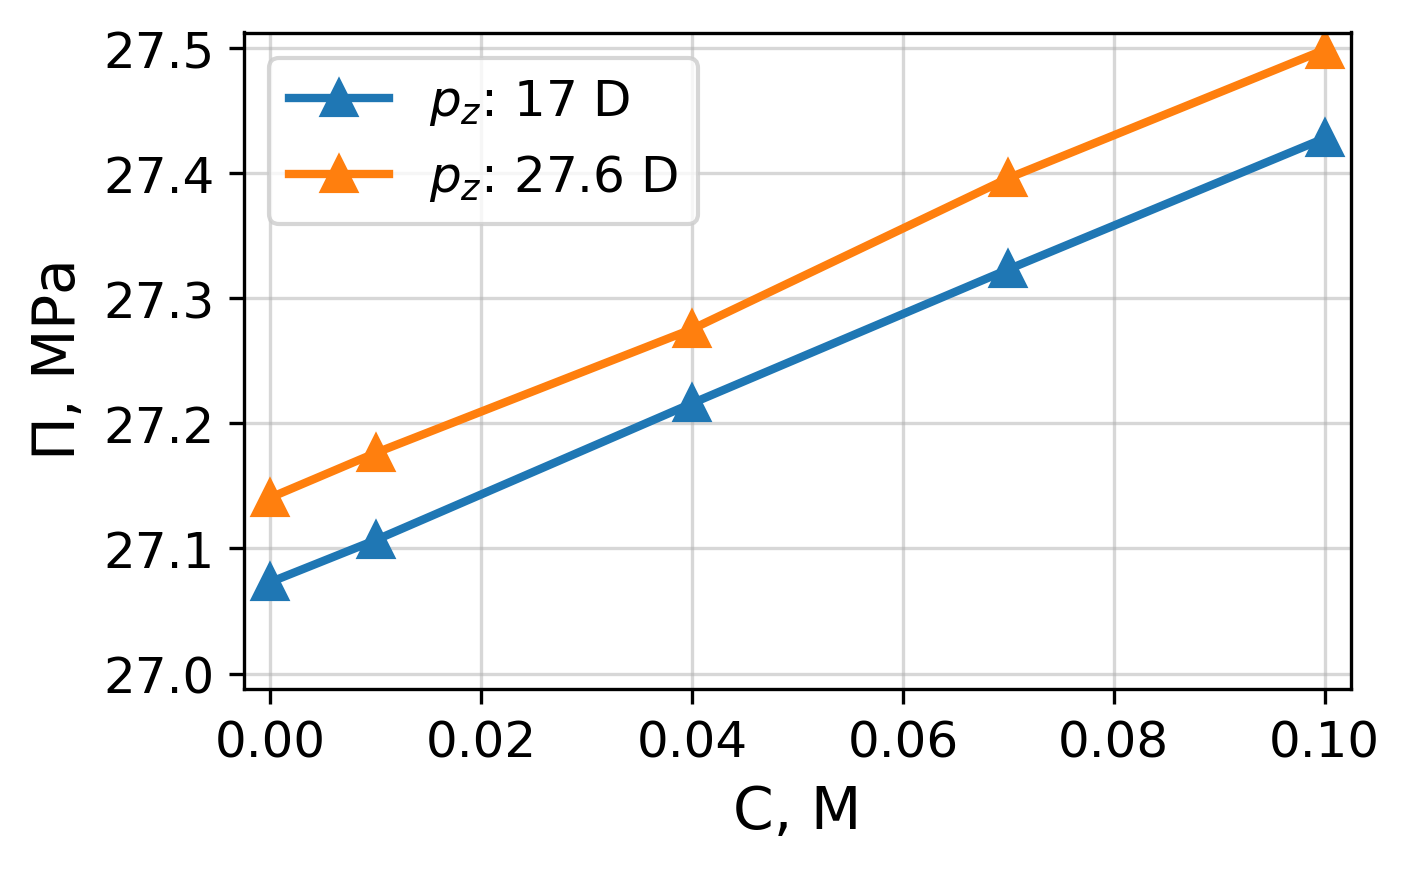

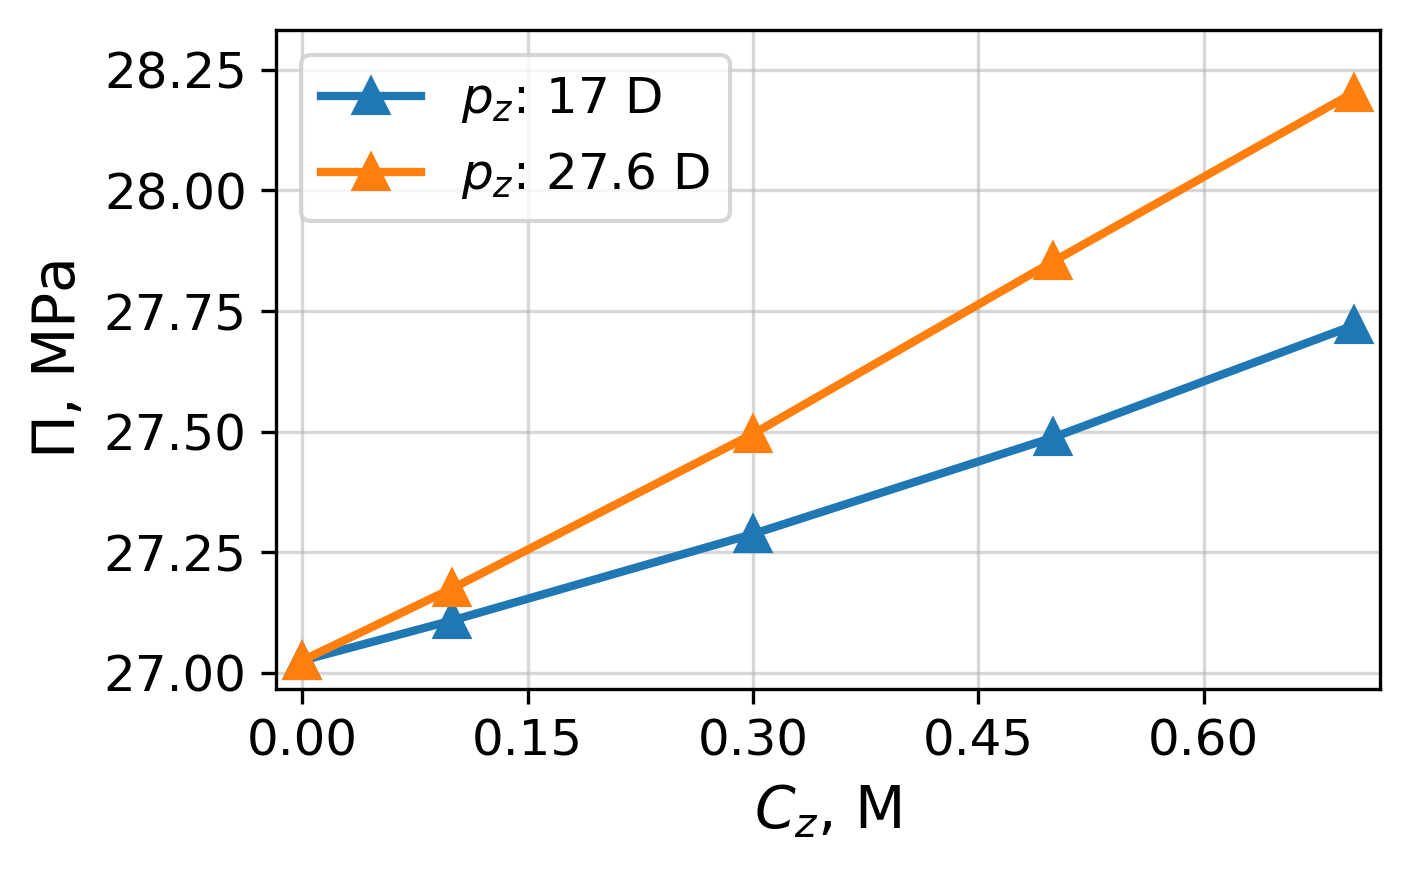

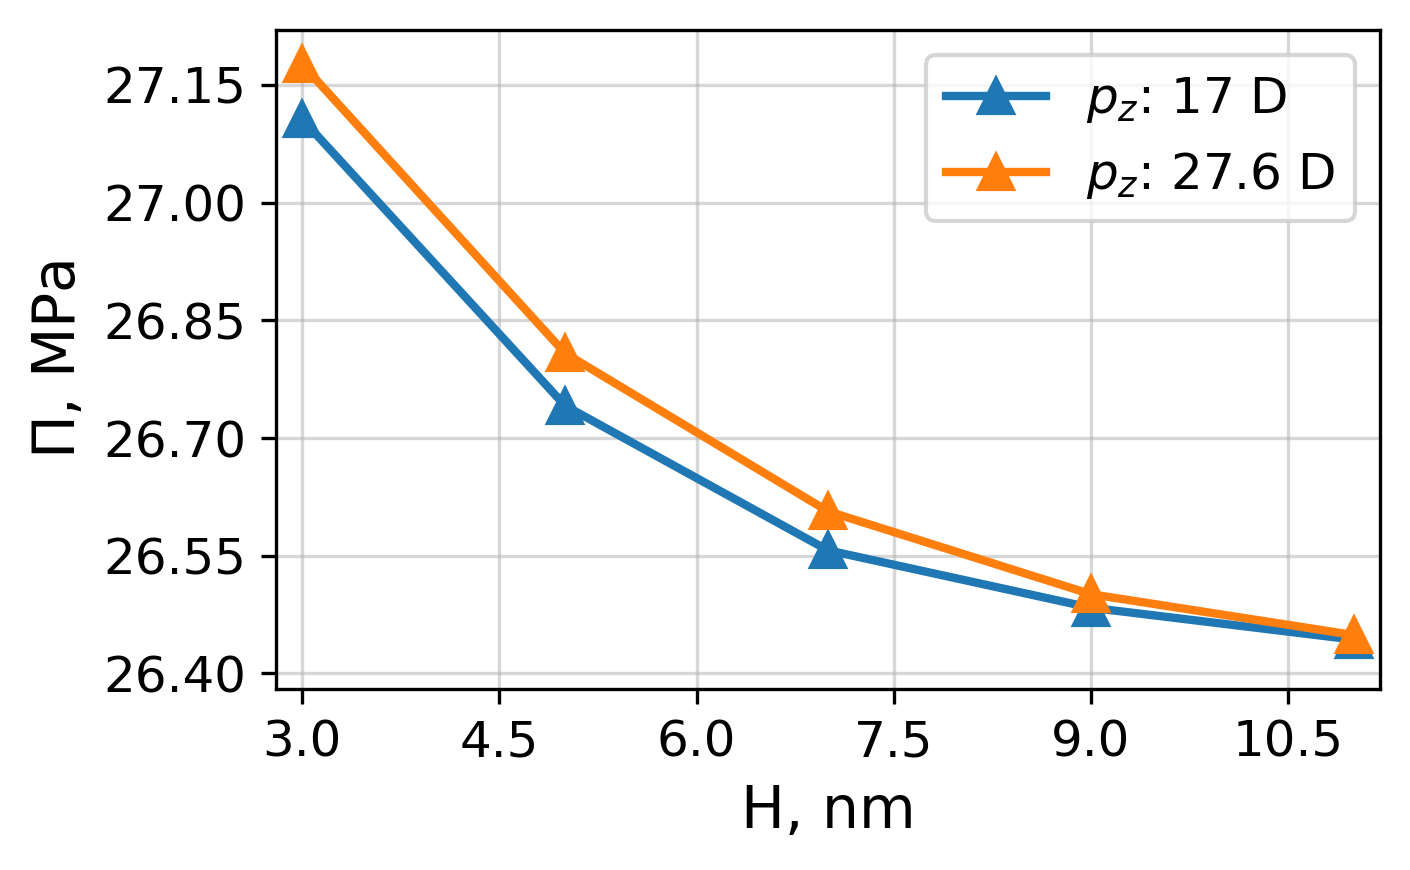

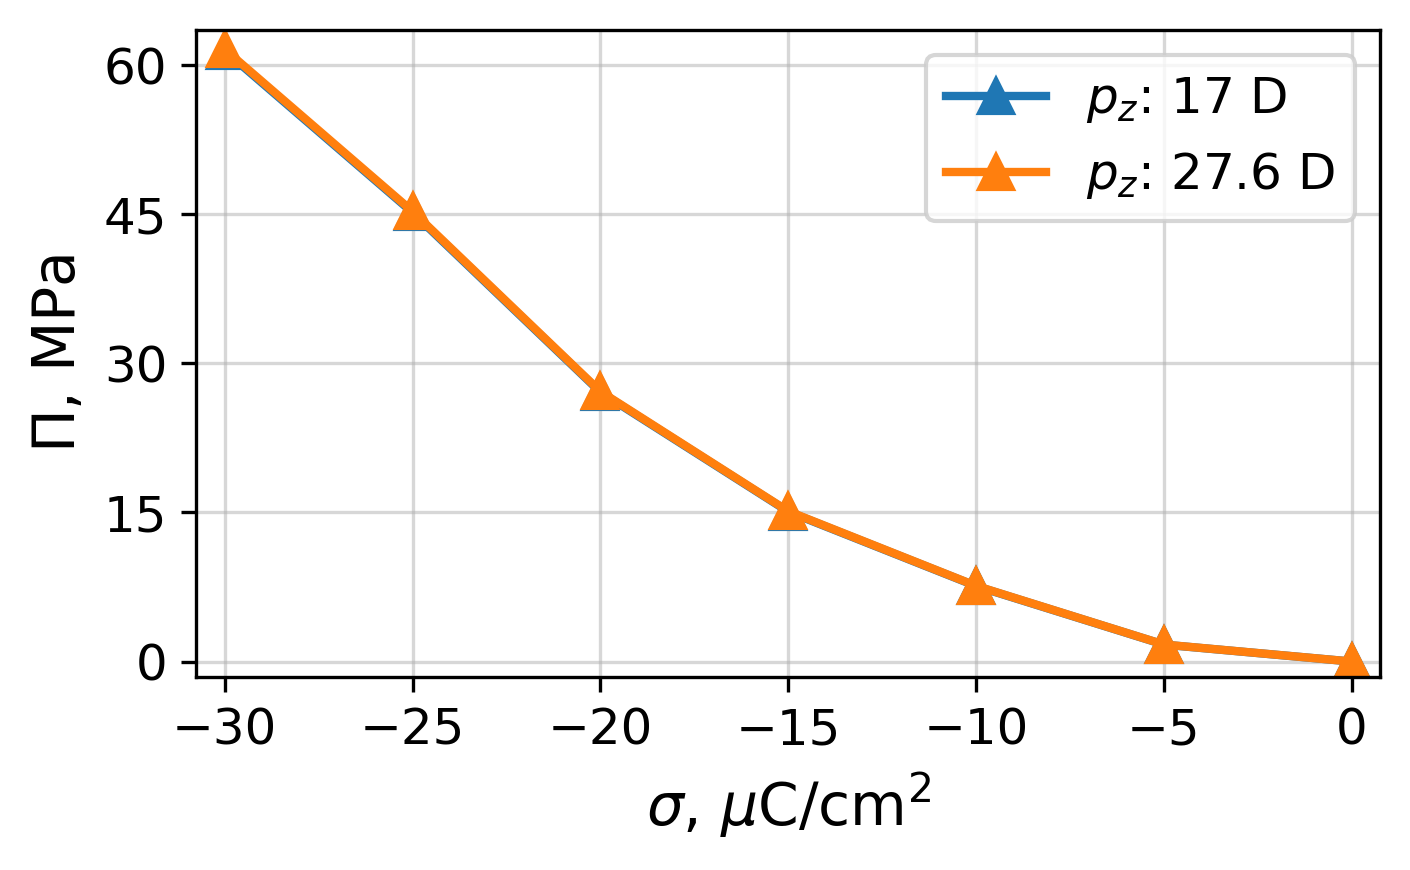

In [57]:
target = 'solvation_force'

scale = 1.2

for sweep in ['C', 'Cz', 'H', 'sigma']:
    fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)
    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    xy_pairs = []

    for pzi, pz in enumerate(['pz_17', 'pz_27p6']):
        x_list = []
        y_list = []
        param_str_list = []
        for folder in os.listdir(osp.join('results_prod', pz, sweep)):
            param = folder.split('_')
            idx = len(param) - param[::-1].index(sweep) - 1
            sweep_param = float(param[idx+1]) if '.' in param[idx+1] else int(param[idx+1])
            param_str_list.append(f'{sweep}: {sweep_param}')

            path = osp.join('results_prod', pz, sweep, folder)
            df = pd.read_csv(osp.join(path, 'simulation_data.csv'))

            x_list.append(sweep_param)
            y_list.append(1.66 * np.abs(np.mean(df[target])))

        x_array = np.array(x_list)
        y_array = np.array(y_list)

        argsort = np.argsort(x_array)
        x_array = x_array[argsort]
        y_array = y_array[argsort]

        # Save to list for global min/max later
        xy_pairs.append((x_array, y_array))

        # Update x and y global min/max for common axis limits across both curves
        if len(x_array) > 0:
            x_min = min(x_min, x_array.min())
            x_max = max(x_max, x_array.max())
        if len(y_array) > 0:
            y_min = min(y_min, y_array.min())
            y_max = max(y_max, y_array.max())

    if y_max - y_min > 10:
        digits = 0
    else:
        digits = 1

    y_min = np.round(np.floor(y_min * 10**digits) / 10**digits, digits)
    y_max = np.round(np.ceil(y_max * 10**digits) / 10**digits, digits)

    if x_max - x_min > 5:
        digits = 0
    else:
        digits = 1

    x_min = np.round(np.floor(x_min * 10**digits) / 10**digits, digits)
    x_max = np.round(np.ceil(x_max * 10**digits) / 10**digits, digits)

    # Set padding for limits, as a % of span or small epsilon
    x_pad = 0.025 * (x_max - x_min) if x_max > x_min else 0.5
    y_pad = 0.025 * (y_max - y_min) if y_max > y_min else 0.5

    # Define centered limits so the outermost tick/grid is not right on the edge
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Plot again with correct limits
    for pzi, (x_array, y_array) in enumerate(xy_pairs):
        ax.plot(
            x_array,
            y_array,
            label=r'$p_z$: 17 D' if pzi == 0 else r'$p_z$: 27.6 D',
            color=COLORS[pzi],
            linewidth=2,
            marker="^",  # triangle marker
            markersize=8,
        )

    # Automatic ticks to fill axis including at the ends
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))

    ax.grid(alpha=0.5)

    if sweep == 'C':
        ax.set_xlabel('C, M', fontsize=14)
    elif sweep == 'Cz':
        ax.set_xlabel(r'$C_z$, M', fontsize=14)
    elif sweep == 'H':
        ax.set_xlabel('H, nm', fontsize=14)
    elif sweep == 'sigma':
        ax.set_xlabel(r'$\sigma$, $\mu$C/cm$^2$', fontsize=14)
    ax.set_ylabel(r'$\Pi$, MPa', fontsize=14)

    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
np.trapezoid(profile["density_profile"], profile["z_centers"])

np.float64(0.0996323442)

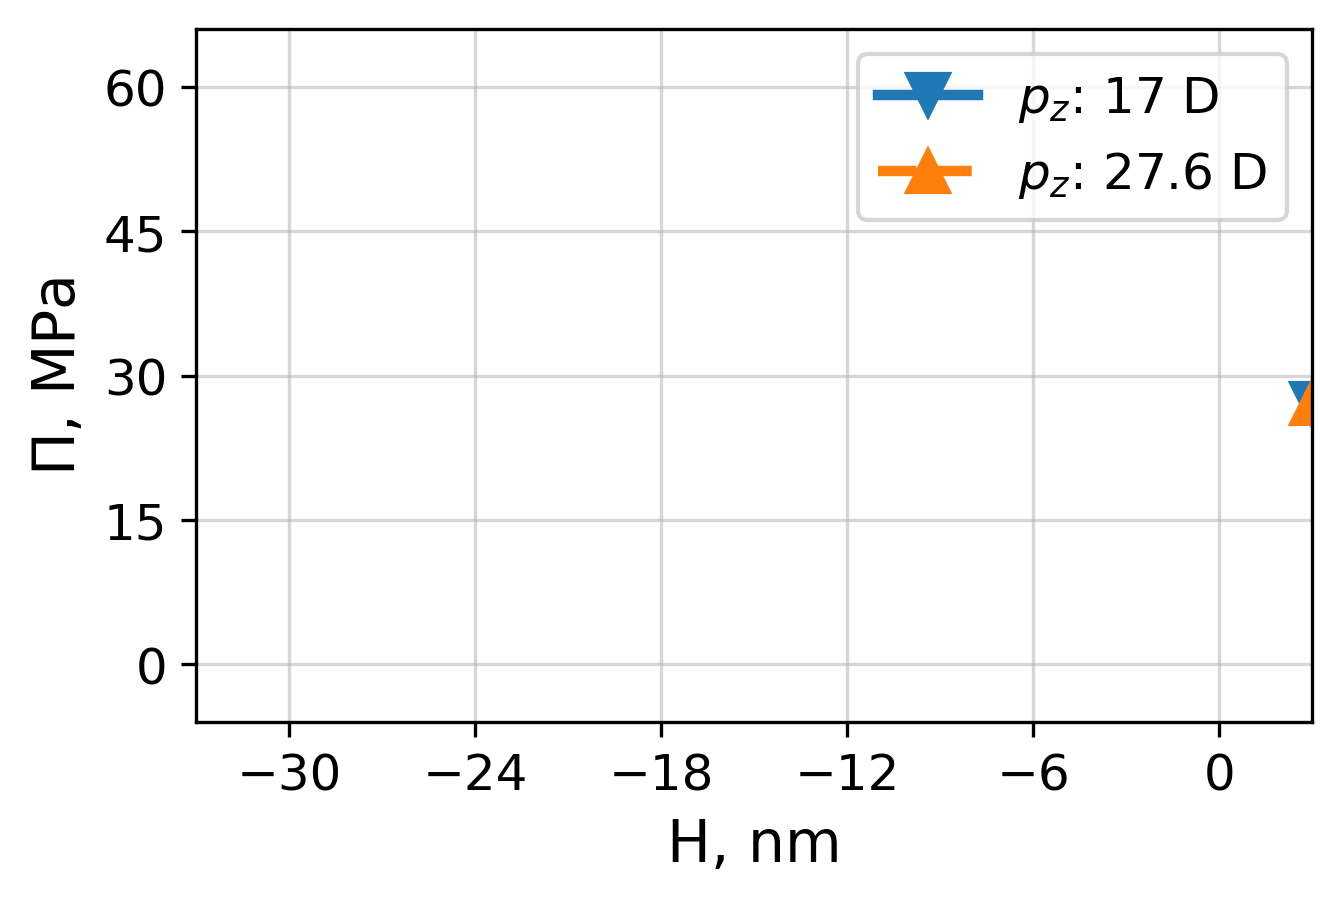

In [ ]:
target = 'solvation_force'


scale = 1.2

for sweep in ['sigma']:
    fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)
    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    xy_pairs = []

    for pzi, pz in enumerate(['pz_17', 'pz_27p6']):
        x_list = []
        y_list = []
        param_str_list = []
        for folder in os.listdir(osp.join('results_prod', pz, sweep)):
            param = folder.split('_')
            idx = len(param) - param[::-1].index(sweep) - 1
            sweep_param = float(param[idx+1]) if '.' in param[idx+1] else int(param[idx+1])
            param_str_list.append(f'{sweep}: {sweep_param}')

            path = osp.join('results_prod', pz, sweep, folder)
            df = pd.read_csv(osp.join(path, 'simulation_data.csv'))

            x_list.append(sweep_param)
            y_list.append(1.66 * np.abs(np.mean(df[target])))

        x_array = np.array(x_list)
        y_array = np.array(y_list)

        argsort = np.argsort(x_array)
        x_array = x_array[argsort]
        y_array = y_array[argsort]

        # Save to list for global min/max later
        xy_pairs.append((x_array, y_array))

        # # Update x and y global min/max for common axis limits across both curves
        # if len(x_array) > 0:
        #     x_min = min(x_min, x_array.min())
        #     x_max = max(x_max, x_array.max())
        # if len(y_array) > 0:
        #     y_min = min(y_min, y_array.min())
        #     y_max = max(y_max, y_array.max())

    # if y_max - y_min > 10:
    #     digits = 0
    # else:
    #     digits = 1

    # y_min = np.round(np.floor(y_min * 10**digits) / 10**digits, digits)
    # y_max = np.round(np.ceil(y_max * 10**digits) / 10**digits, digits)

    # if x_max - x_min > 5:
    #     digits = 0
    # else:
    #     digits = 1

    # x_min = np.round(np.floor(x_min * 10**digits) / 10**digits, digits)
    # x_max = np.round(np.ceil(x_max * 10**digits) / 10**digits, digits)

    # # Set padding for limits, as a % of span or small epsilon
    # x_pad = 0.025 * (x_max - x_min) if x_max > x_min else 0.5
    # y_pad = 0.025 * (y_max - y_min) if y_max > y_min else 0.5

    # # Define centered limits so the outermost tick/grid is not right on the edge
    # ax.set_xlim(x_min - x_pad, x_max + x_pad)
    # ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Plot again with correct limits
    for pzi, (x_array, y_array) in enumerate(xy_pairs):
        ax.plot(
            x_array,
            y_array,
            label=r'$p_z$: 17 D' if pzi == 0 else r'$p_z$: 27.6 D',
            color=COLORS[pzi],
            linestyle='-' if pzi == 0 else '--',
            linewidth=2.5,
            marker="v" if pzi == 0 else "^",  # triangle marker
            markersize=10,
        )

    x_min, x_max = -30, 0
    y_min, y_max = 0, 60
    ax.set_xticks(np.linspace(x_min, x_max, 5, endpoint=True, dtype=int))
    ax.set_yticks(np.linspace(y_min, y_max, 15, endpoint=True, dtype=int))

    pct = 0.1
    ax.set_xlim(x_min - pct * (x_max - x_min), x_max + pct * (x_max - x_min))
    ax.set_ylim(y_min - pct * (y_max - y_min), y_max + pct * (y_max - y_min))

    # Automatic ticks to fill axis including at the ends
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))

    ax.grid(alpha=0.5)

    if sweep == 'C':
        ax.set_xlabel('C, M', fontsize=14)
    elif sweep == 'Cz':
        ax.set_xlabel(r'$C_z$, M', fontsize=14)
    elif sweep == 'H':
        ax.set_xlabel('H, nm', fontsize=14)
    elif sweep == 'sigma':
        ax.set_xlabel(r'$\sigma$, $\mu$C/cm$^2$', fontsize=14)
    ax.set_ylabel(r'$\Pi$, MPa', fontsize=14)

    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)
    plt.show()


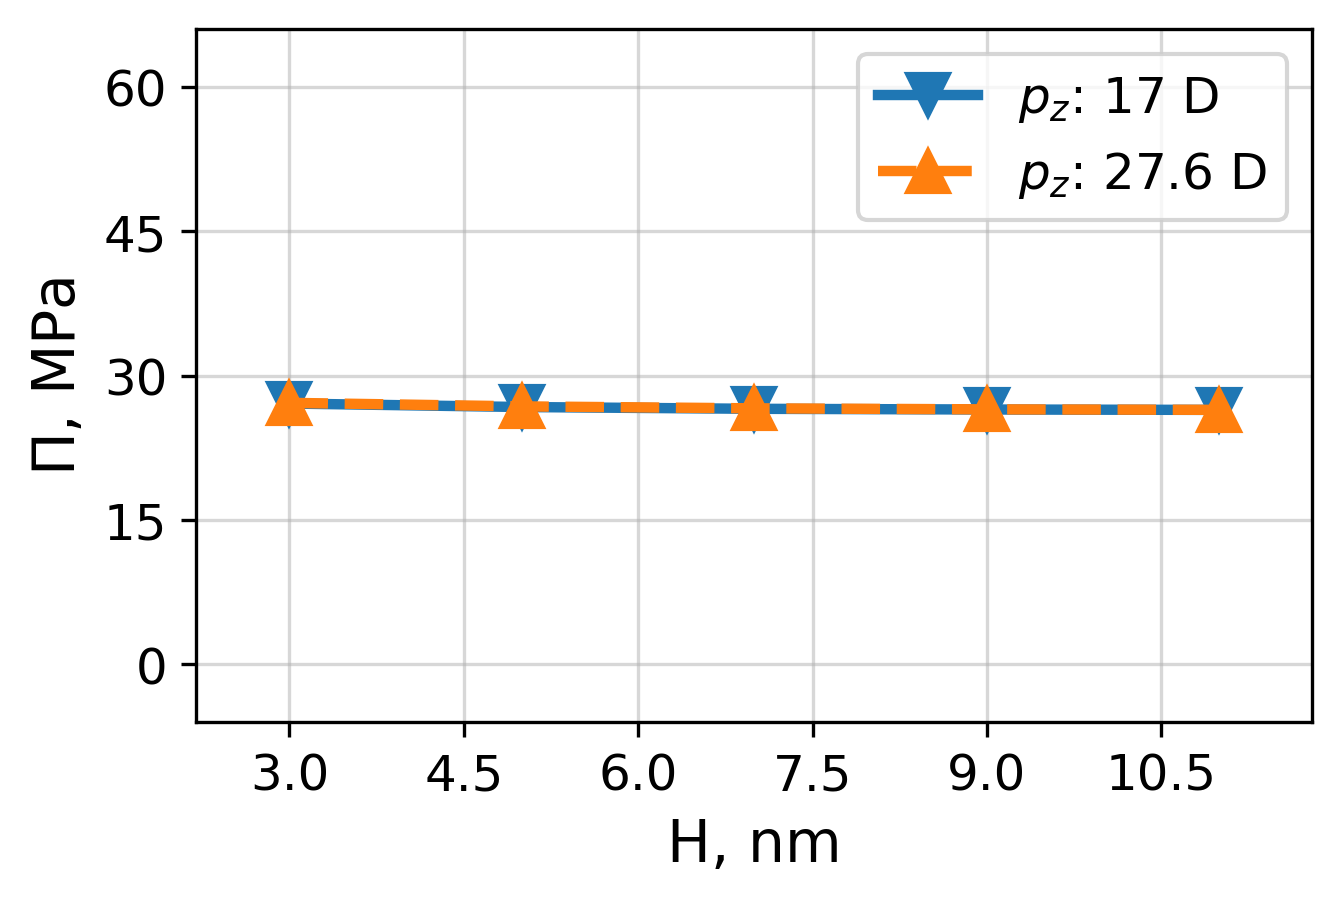

In [59]:
target = 'solvation_force'


scale = 1.2

for sweep in ['H']:
    fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)
    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    xy_pairs = []

    for pzi, pz in enumerate(['pz_17', 'pz_27p6']):
        x_list = []
        y_list = []
        param_str_list = []
        for folder in os.listdir(osp.join('results_prod', pz, sweep)):
            param = folder.split('_')
            idx = len(param) - param[::-1].index(sweep) - 1
            sweep_param = float(param[idx+1]) if '.' in param[idx+1] else int(param[idx+1])
            param_str_list.append(f'{sweep}: {sweep_param}')

            path = osp.join('results_prod', pz, sweep, folder)
            df = pd.read_csv(osp.join(path, 'simulation_data.csv'))

            x_list.append(sweep_param)
            y_list.append(1.66 * np.abs(np.mean(df[target])))

        x_array = np.array(x_list)
        y_array = np.array(y_list)

        argsort = np.argsort(x_array)
        x_array = x_array[argsort]
        y_array = y_array[argsort]

        # Save to list for global min/max later
        xy_pairs.append((x_array, y_array))

        # # Update x and y global min/max for common axis limits across both curves
        # if len(x_array) > 0:
        #     x_min = min(x_min, x_array.min())
        #     x_max = max(x_max, x_array.max())
        # if len(y_array) > 0:
        #     y_min = min(y_min, y_array.min())
        #     y_max = max(y_max, y_array.max())

    # if y_max - y_min > 10:
    #     digits = 0
    # else:
    #     digits = 1

    # y_min = np.round(np.floor(y_min * 10**digits) / 10**digits, digits)
    # y_max = np.round(np.ceil(y_max * 10**digits) / 10**digits, digits)

    # if x_max - x_min > 5:
    #     digits = 0
    # else:
    #     digits = 1

    # x_min = np.round(np.floor(x_min * 10**digits) / 10**digits, digits)
    # x_max = np.round(np.ceil(x_max * 10**digits) / 10**digits, digits)

    # # Set padding for limits, as a % of span or small epsilon
    # x_pad = 0.025 * (x_max - x_min) if x_max > x_min else 0.5
    # y_pad = 0.025 * (y_max - y_min) if y_max > y_min else 0.5

    # # Define centered limits so the outermost tick/grid is not right on the edge
    # ax.set_xlim(x_min - x_pad, x_max + x_pad)
    # ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Plot again with correct limits
    for pzi, (x_array, y_array) in enumerate(xy_pairs):
        ax.plot(
            x_array,
            y_array,
            label=r'$p_z$: 17 D' if pzi == 0 else r'$p_z$: 27.6 D',
            color=COLORS[pzi],
            linestyle='-' if pzi == 0 else '--',
            linewidth=2.5,
            marker="v" if pzi == 0 else "^",  # triangle marker
            markersize=10,
        )

    x_min, x_max = 3, 11
    y_min, y_max = 0, 60
    ax.set_xticks(np.linspace(x_min, x_max, 5, endpoint=True, dtype=int))
    ax.set_yticks(np.linspace(y_min, y_max, 15, endpoint=True, dtype=int))

    pct = 0.1
    ax.set_xlim(x_min - pct * (x_max - x_min), x_max + pct * (x_max - x_min))
    ax.set_ylim(y_min - pct * (y_max - y_min), y_max + pct * (y_max - y_min))

    # Automatic ticks to fill axis including at the ends
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))

    ax.grid(alpha=0.5)

    if sweep == 'C':
        ax.set_xlabel('C, M', fontsize=14)
    elif sweep == 'Cz':
        ax.set_xlabel(r'$C_z$, M', fontsize=14)
    elif sweep == 'H':
        ax.set_xlabel('H, nm', fontsize=14)
    elif sweep == 'sigma':
        ax.set_xlabel(r'$\sigma$, $\mu$C/cm$^2$', fontsize=14)
    ax.set_ylabel(r'$\Pi$, MPa', fontsize=14)

    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)
    plt.show()


---

In [50]:
import yaml
from density_profile import read_xyz_trajectory

RESULTS_ROOT = "results_prod"
PZ_LIST = ["pz_17", "pz_27p6"]
SWEEP = "Cz"
POSITIVE_SPECIES = ("Na",)
CACHE_FILENAME = "positive_profile_cache.npz"
REBUILD_CACHE = False  # Set True to force regeneration of cached data


def extract_param_from_name(folder_name: str, key: str):
    """Fallback parser for parameter values encoded in folder names."""
    parts = folder_name.split("_")
    for idx, token in enumerate(parts):
        if token == key and idx + 1 < len(parts):
            try:
                return float(parts[idx + 1])
            except ValueError:
                return None
    return None


def ensure_positive_cache(calc_dir: str, config: dict) -> str:
    """Persist per-frame Na z-coordinates + box geometry for later post-processing."""
    cache_path = osp.join(calc_dir, CACHE_FILENAME)
    if osp.isfile(cache_path) and not REBUILD_CACHE:
        return cache_path

    traj_path = osp.join(calc_dir, "trajectory.xyz")
    if not osp.isfile(traj_path):
        raise FileNotFoundError(f"Missing trajectory in {calc_dir}")

    if "r_Na" not in config:
        raise KeyError(f"Config missing 'r_Na' in {calc_dir}")

    positions, species, _charges, boxes, _energies = read_xyz_trajectory(traj_path)

    Lx = float(boxes[0, 0])
    Ly = float(boxes[0, 4])
    H = float(config.get("H", boxes[0, 8]))
    r_na = float(config["r_Na"])

    positive_z = []
    for frame_idx in range(positions.shape[0]):
        frame_positions = positions[frame_idx]
        frame_species = species[frame_idx]
        mask = np.isin(frame_species, POSITIVE_SPECIES)
        positive_z.append(frame_positions[mask, 2].astype(np.float64, copy=True))

    np.savez(
        cache_path,
        positive_z=np.array(positive_z, dtype=object),
        H=H,
        Lx=Lx,
        Ly=Ly,
        r_Na=r_na,
        n_frames=len(positive_z),
    )
    return cache_path


calc_records = []
for pz in PZ_LIST:
    sweep_dir = osp.join(RESULTS_ROOT, pz, SWEEP)
    if not osp.isdir(sweep_dir):
        print(f"Sweep directory not found: {sweep_dir}")
        continue
    for folder in sorted(os.listdir(sweep_dir)):
        calc_dir = osp.join(sweep_dir, folder)
        config_path = osp.join(calc_dir, "config_backup.yaml")
        traj_path = osp.join(calc_dir, "trajectory.xyz")
        if not (osp.isfile(config_path) and osp.isfile(traj_path)):
            continue
        calc_records.append((pz, calc_dir, folder))

record_count = len(calc_records)
if record_count == 0:
    print("No Cz calculations with both config and trajectory files were found.")
else:
    print(f"Found {record_count} Cz calculation folders. Building/validating caches...")
    processed_records = []
    for idx, (pz, calc_dir, folder) in enumerate(calc_records, start=1):
        config_path = osp.join(calc_dir, "config_backup.yaml")
        remaining = record_count - idx
        print(f"[{idx}/{record_count}] Preparing {calc_dir} (remaining: {remaining})")
        try:
            with open(config_path, "r") as f:
                config = yaml.safe_load(f) or {}

            cache_path = ensure_positive_cache(calc_dir, config)

            cz_value = config.get("Cz")
            if cz_value is None:
                cz_value = extract_param_from_name(folder, "Cz")
            if cz_value is None:
                raise ValueError("Unable to determine Cz value for this folder.")

            processed_records.append(
                {
                    "pz_label": pz,
                    "parameter_value": float(cz_value),
                    "result_path": calc_dir,
                    "cache_path": cache_path,
                    "config_path": config_path,
                }
            )
        except Exception as exc:
            print(f"Skipping {calc_dir}: {exc}")

    calc_records = processed_records
    print(f"Cached Na trajectories for {len(calc_records)} calculations.")


Found 10 Cz calculation folders. Building/validating caches...
[1/10] Preparing results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.1_20251124_154701 (remaining: 9)
[2/10] Preparing results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.3_20251124_154701 (remaining: 8)
[3/10] Preparing results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.5_20251124_154701 (remaining: 7)
[4/10] Preparing results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.7_20251124_154702 (remaining: 6)
[5/10] Preparing results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0_20251124_154701 (remaining: 5)
[6/10] Preparing results_prod/pz_27p6/Cz/ions_dipole_Cz_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.1_20251124_154912 (remaining: 4)
[7/10] Preparing results_prod/pz_27p6/Cz/ions_dipole_Cz_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.3_20251124_154912 (remaining: 3)
[8/10] Preparing results_prod/pz_27p6/Cz/ions_dipole_Cz_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.5_202511

Building density profiles and cosh fits from cached data...
[1/10] Processing cache: results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.1_20251124_154701/positive_profile_cache.npz
[2/10] Processing cache: results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.3_20251124_154701/positive_profile_cache.npz
[3/10] Processing cache: results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.5_20251124_154701/positive_profile_cache.npz
[4/10] Processing cache: results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.7_20251124_154702/positive_profile_cache.npz
[5/10] Processing cache: results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0_20251124_154701/positive_profile_cache.npz
[6/10] Processing cache: results_prod/pz_27p6/Cz/ions_dipole_Cz_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.1_20251124_154912/positive_profile_cache.npz
[7/10] Processing cache: results_prod/pz_27p6/Cz/ions_dipole_Cz_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.3_2025

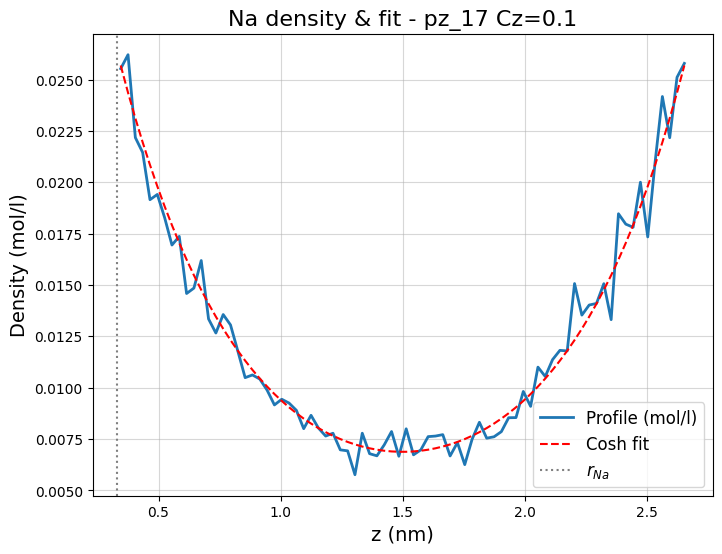

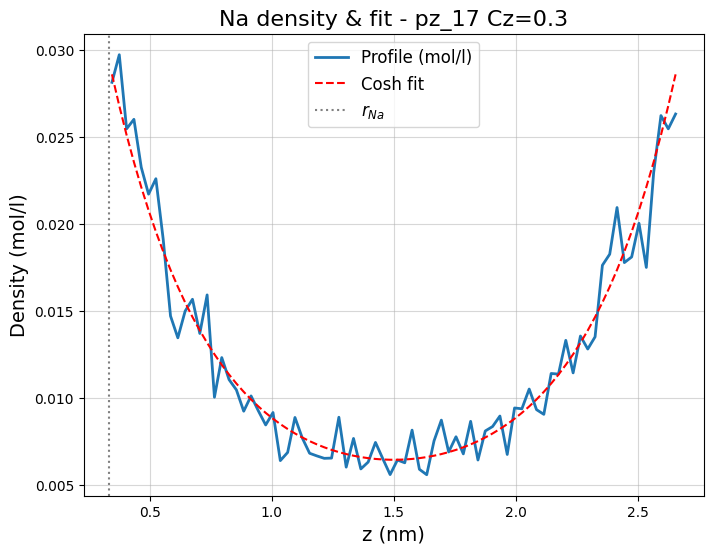

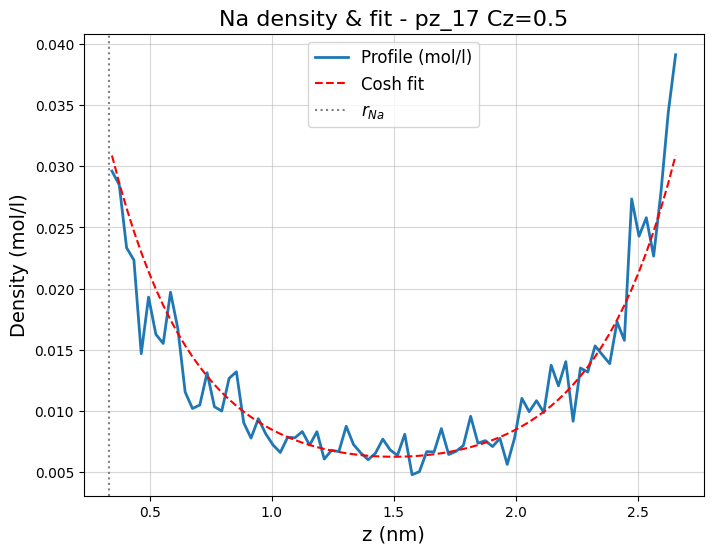

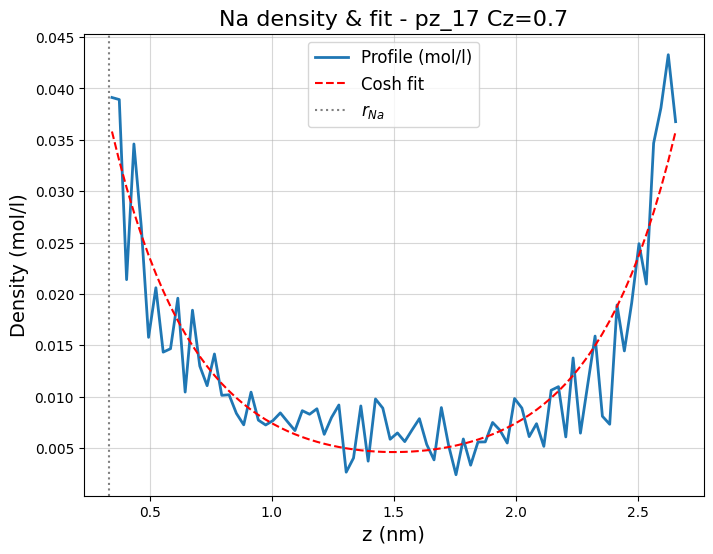

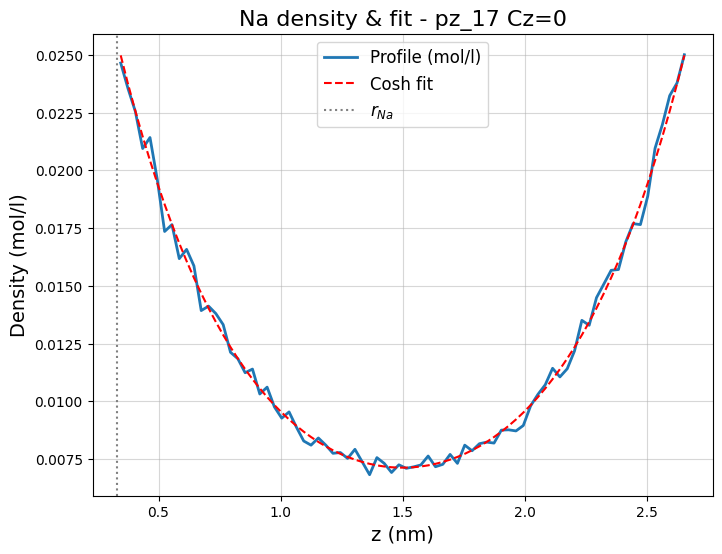

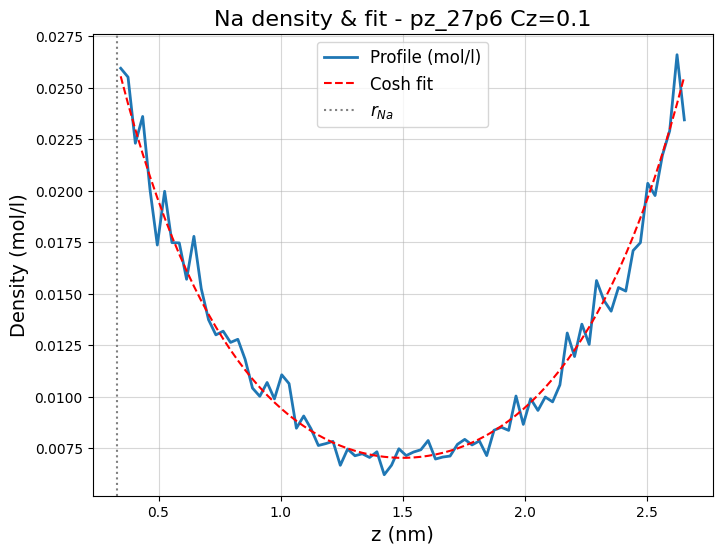

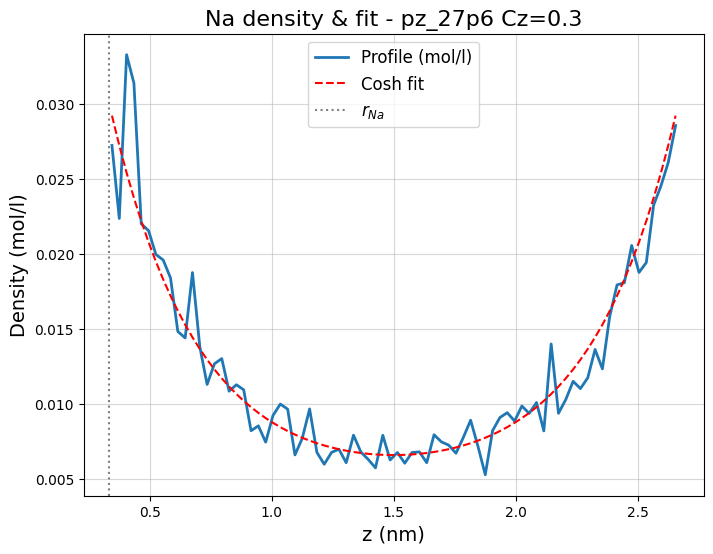

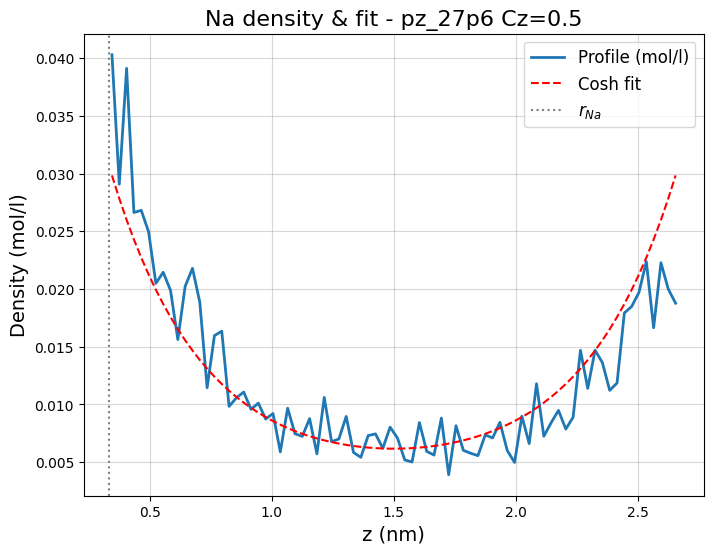

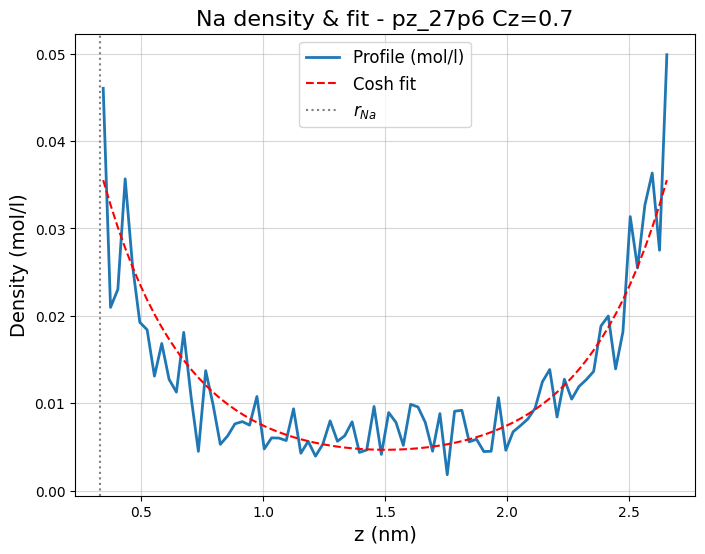

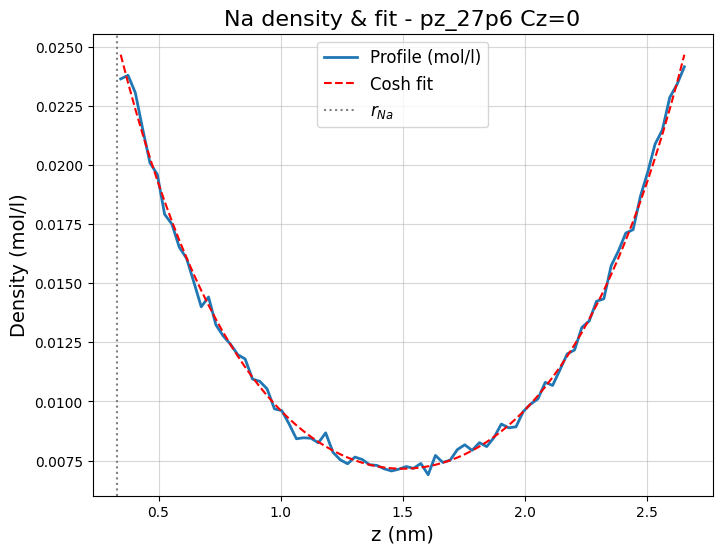

In [51]:
from typing import Dict, Tuple

PROFILE_BINS = 100
BETA_MIN = 1e-3
BETA_MAX = 3.0
BETA_STEPS = 200
BETA_LOCAL_STEPS = 120
MOL_CONV = 1.66053907  # 1/nm^3 -> mol/l


def load_density_profile(cache_path: str, n_bins: int) -> Dict[str, np.ndarray | float]:
    with np.load(cache_path, allow_pickle=True) as data:
        positive_z = data["positive_z"]
        H = float(data["H"])
        Lx = float(data["Lx"])
        Ly = float(data["Ly"])
        r_na = float(data["r_Na"])

    if len(positive_z) == 0:
        raise ValueError("Cached file does not contain any frames.")

    area_xy = Lx * Ly
    z_edges = np.linspace(0.0, H, n_bins + 1, dtype=np.float64)
    bin_height = z_edges[1] - z_edges[0]
    bin_volume = area_xy * bin_height

    accum_counts = np.zeros(n_bins, dtype=np.float64)
    for frame_z in positive_z:
        frame_z = np.asarray(frame_z, dtype=np.float64)
        if frame_z.size == 0:
            continue
        counts, _ = np.histogram(frame_z, bins=z_edges)
        accum_counts += counts

    mean_counts = accum_counts / len(positive_z)
    density_mol_l = (mean_counts / bin_volume) * MOL_CONV
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

    valid_mask = (z_centers >= r_na) & (z_centers <= (H - r_na))
    if not np.any(valid_mask):
        raise ValueError("No valid bins remain after removing wall regions.")

    z_centers = z_centers[valid_mask]
    density_mol_l = density_mol_l[valid_mask]

    return {
        "H": H,
        "Lx": Lx,
        "Ly": Ly,
        "r_na": r_na,
        "z_centers": z_centers,
        "density_profile": density_mol_l,
        "n_frames": len(positive_z),
    }


def fit_cosh_profile(z_centers: np.ndarray, densities: np.ndarray, H: float) -> Tuple[float, float, float]:
    center = H / 2.0
    z_shift = z_centers - center

    def solve_for_beta(beta: float) -> Tuple[float, float, float, float]:
        cosh_term = np.cosh(beta * z_shift)
        X = np.column_stack([cosh_term, np.ones_like(z_shift)])
        params, *_ = np.linalg.lstsq(X, densities, rcond=None)
        a, c = params
        model = a * cosh_term + c
        residual = densities - model
        mse = float(np.mean(residual**2))
        return mse, a, beta, c

    best = None
    for beta in np.linspace(BETA_MIN, BETA_MAX, BETA_STEPS):
        result = solve_for_beta(beta)
        if not np.isfinite(result[0]):
            continue
        if best is None or result[0] < best[0]:
            best = result

    if best is None:
        raise RuntimeError("Unable to find initial cosh fit.")

    _, _, best_beta, _ = best
    local_min = max(BETA_MIN, best_beta * 0.5)
    local_max = min(BETA_MAX, best_beta * 1.5)
    for beta in np.linspace(local_min, local_max, BETA_LOCAL_STEPS):
        result = solve_for_beta(beta)
        if not np.isfinite(result[0]):
            continue
        if result[0] < best[0]:
            best = result

    return best[1], best[2], best[3]


def evaluate_cosh(z: np.ndarray | float, params: Tuple[float, float, float], H: float) -> np.ndarray:
    a, beta, c = params
    center = H / 2.0
    return a * np.cosh(beta * (np.asarray(z) - center)) + c


profile_results = []
if not calc_records:
    print("No cached Cz calculations available. Run the previous cell first.")
else:
    print("Building density profiles and cosh fits from cached data...")
    for idx, record in enumerate(calc_records, start=1):
        cache_path = record["cache_path"]
        print(f"[{idx}/{len(calc_records)}] Processing cache: {cache_path}")
        try:
            profile = load_density_profile(cache_path, PROFILE_BINS)
            fit_params = fit_cosh_profile(
                profile["z_centers"], profile["density_profile"], profile["H"]
            )
            fitted = evaluate_cosh(profile["z_centers"], fit_params, profile["H"])
            rmse = float(np.sqrt(np.mean((profile["density_profile"] - fitted) ** 2)))
            surface_value = float(evaluate_cosh(profile["r_na"], fit_params, profile["H"]))

            profile_results.append(
                {
                    **record,
                    **profile,
                    "fit_params": {
                        "a": fit_params[0],
                        "beta": fit_params[1],
                        "c": fit_params[2],
                    },
                    "surface_concentration": surface_value,
                    "fit_rmse": rmse,
                }
            )
        except Exception as exc:
            print(f"Skipping cache {cache_path}: {exc}")

    print(f"Constructed {len(profile_results)} density profiles.")

if profile_results:
    for rec in profile_results:
        params_tuple = (
            rec["fit_params"]["a"],
            rec["fit_params"]["beta"],
            rec["fit_params"]["c"],
        )
        plt.figure(figsize=(8, 6))
        plt.grid(alpha=0.5)
        plt.plot(rec["z_centers"], rec["density_profile"], label="Profile (mol/l)", linewidth=2)
        # print('C:', np.trapezoid(rec["density_profile"], rec["z_centers"]))
        plt.plot(
            rec["z_centers"],
            evaluate_cosh(rec["z_centers"], params_tuple, rec["H"]),
            label="Cosh fit",
            linestyle="--",
            linewidth=1.5,
            color="red",
        )
        print('C:', np.trapezoid(evaluate_cosh(rec["z_centers"], params_tuple, rec["H"]), rec["z_centers"]))
        plt.axvline(rec["r_na"], color="gray", linestyle=":", label=r"$r_{Na}$")
        plt.xlabel("z (nm)", fontsize=14)
        plt.ylabel("Density (mol/l)", fontsize=14)
        plt.title(
            f"Na density & fit - {rec['pz_label']} Cz={rec['parameter_value']:.3g}", fontsize=16
        )
        plt.legend(fontsize=12)
        # plt.show()


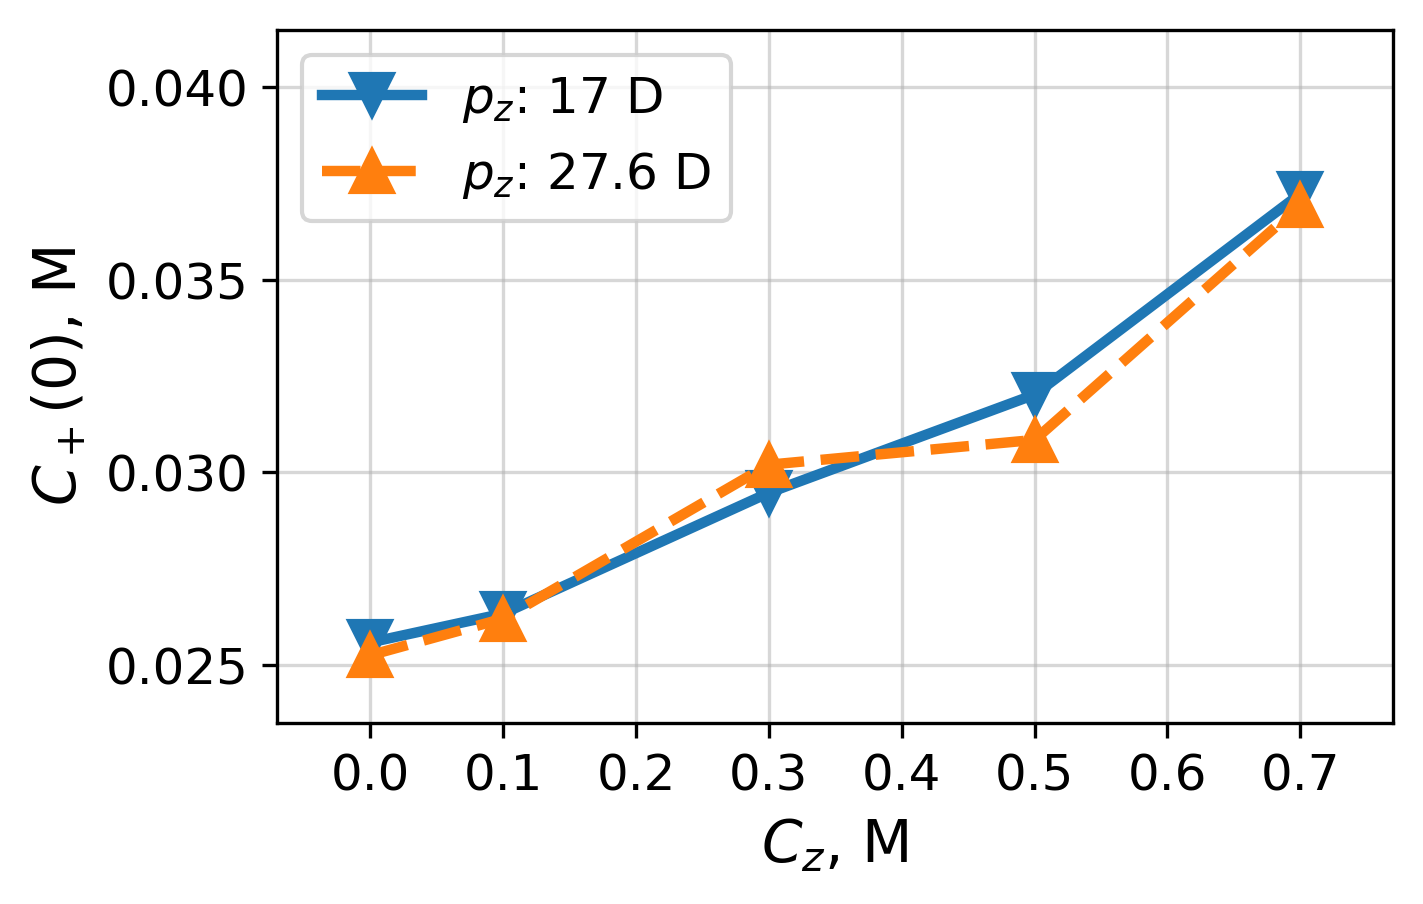

In [56]:
scale = 1.2

if not profile_results:
    print("No Cz surface concentration data collected.")
else:
    fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)
    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    xy_pairs = []

    for pzi, pz in enumerate(PZ_LIST):
        pz_data = [record for record in profile_results if record["pz_label"] == pz]
        if not pz_data:
            continue

        pz_data.sort(key=lambda record: record["parameter_value"])
        cz_values = np.array([record["parameter_value"] for record in pz_data], dtype=np.float64)
        surface_values = np.array([record["surface_concentration"] for record in pz_data], dtype=np.float64)

        argsort = np.argsort(cz_values)
        cz_values = cz_values[argsort]
        surface_values = surface_values[argsort]

        xy_pairs.append((cz_values, surface_values))

    # axes ranges -- override with fixed limits similar to code style @ lines 2-112
    x_min, x_max = 0, 0.7
    y_min, y_max = 0.025, 0.04
    pct = 0.1

    # Plot again with correct limits and styling
    for pzi, (cz_values, surface_values) in enumerate(xy_pairs):
        ax.plot(
            cz_values,
            surface_values,
            label=r"$p_z$: 17 D" if PZ_LIST[pzi] == "pz_17" else r"$p_z$: 27.6 D",
            color=COLORS[pzi],
            linestyle='-' if pzi == 0 else '--',
            linewidth=2.5,
            marker="v" if pzi == 0 else "^",
            markersize=10,
        )

    ax.set_xticks(np.linspace(x_min, x_max, 8, endpoint=True))
    ax.set_yticks(np.linspace(y_min, y_max, 4, endpoint=True))

    ax.set_xlim(x_min - pct * (x_max - x_min), x_max + pct * (x_max - x_min))
    ax.set_ylim(y_min - pct * (y_max - y_min), y_max + pct * (y_max - y_min))

    # ax.xaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))
    # ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))

    ax.grid(alpha=0.5)

    ax.set_xlabel(r"$C_z$, M", fontsize=14)
    ax.set_ylabel(r"$C_+(0)$, M", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)
    plt.show()


---

In [ ]:
import yaml
from density_profile import read_xyz_trajectory

# System parameters to match
C = 0.01  # mol/l
Cz = 0.7  # mol/l
sigma = -20  # µC/cm²
H = 3  # nm

# Frame selection for profile calculation
START_FRAME = 4000  # Start from this frame (0 = from beginning)
END_FRAME = None  # End at this frame (None = use all frames)

PZ_LIST = ["pz_17", "pz_27p6"]
RESULTS_ROOT = "results_prod"
MOL_CONV = 1.66053907  # 1/nm^3 -> mol/l
PROFILE_BINS = 50

POSITIVE_SPECIES = ("Na",)
NEGATIVE_SPECIES = ("Cl",)
ZWITTERION_SPECIES = ("G",)  # Only G atoms represent zwitterion centers
TRAJ_CACHE_FILENAME = "trajectory_cache.npz"


def extract_params_from_folder(folder_name: str, config: dict) -> dict:
    """Extract C, Cz, sigma, H from folder name or config."""
    params = {}
    parts = folder_name.split("_")

    for key in ["C", "Cz", "H", "sigma"]:
        if key in config:
            params[key] = float(config[key])
        else:
            for idx, token in enumerate(parts):
                if token == key and idx + 1 < len(parts):
                    try:
                        val = parts[idx + 1]
                        params[key] = float(val)
                        break
                    except (ValueError, IndexError):
                        pass

    return params


def find_matching_folder(pz: str, target_C: float, target_Cz: float, target_sigma: float, target_H: float) -> str | None:
    """Find folder matching the specified parameters."""
    tolerance = 1e-3

    for sweep in ["C", "Cz", "H", "sigma"]:
        sweep_dir = osp.join(RESULTS_ROOT, pz, sweep)
        if not osp.isdir(sweep_dir):
            continue

        for folder in os.listdir(sweep_dir):
            calc_dir = osp.join(sweep_dir, folder)
            config_path = osp.join(calc_dir, "config_backup.yaml")
            traj_path = osp.join(calc_dir, "trajectory.xyz")

            if not (osp.isfile(config_path) and osp.isfile(traj_path)):
                continue

            try:
                with open(config_path, "r") as f:
                    config = yaml.safe_load(f) or {}

                params = extract_params_from_folder(folder, config)

                if all(key in params for key in ["C", "Cz", "sigma", "H"]):
                    if (abs(params["C"] - target_C) < tolerance and
                        abs(params["Cz"] - target_Cz) < tolerance and
                        abs(params["sigma"] - target_sigma) < tolerance and
                        abs(params["H"] - target_H) < tolerance):
                        return calc_dir
            except Exception:
                continue

    return None


def load_or_cache_trajectory(traj_path: str, cache_path: str) -> tuple:
    """Load trajectory, caching to file for faster subsequent reads."""
    if osp.isfile(cache_path):
        print(f"  Loading cached trajectory from {osp.basename(cache_path)}")
        with np.load(cache_path, allow_pickle=True) as data:
            positions = data["positions"]
            species = data["species"]
            boxes = data["boxes"]
        return positions, species, boxes

    print(f"  Reading trajectory from {osp.basename(traj_path)}")
    positions, species, _charges, boxes, _energies = read_xyz_trajectory(traj_path)

    print(f"  Caching trajectory to {osp.basename(cache_path)}")
    np.savez(
        cache_path,
        positions=positions,
        species=species,
        boxes=boxes,
    )

    return positions, species, boxes


def build_density_profile(positions: np.ndarray, species: np.ndarray, boxes: np.ndarray, species_list: tuple, n_bins: int, start_frame: int = 0, end_frame: int | None = None) -> dict:
    """Build density profile for specified species."""
    Lx = float(boxes[0, 0])
    Ly = float(boxes[0, 4])
    H = float(boxes[0, 8])

    n_frames_total = positions.shape[0]
    start_frame = max(0, min(start_frame, n_frames_total - 1))
    end_frame = end_frame if end_frame is not None else n_frames_total
    end_frame = min(end_frame, n_frames_total)

    frame_indices = range(start_frame, end_frame)
    n_frames_used = len(frame_indices)

    if n_frames_used == 0:
        raise ValueError(f"No frames in range [{start_frame}, {end_frame})")

    area_xy = Lx * Ly
    z_edges = np.linspace(0.0, H, n_bins + 1, dtype=np.float64)
    bin_height = z_edges[1] - z_edges[0]
    bin_volume = area_xy * bin_height
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

    accum_counts = np.zeros(n_bins, dtype=np.float64)

    for frame_idx in frame_indices:
        frame_positions = positions[frame_idx]
        frame_species = species[frame_idx]
        mask = np.isin(frame_species, species_list)
        z_coords = frame_positions[mask, 2]

        if z_coords.size > 0:
            counts, _ = np.histogram(z_coords, bins=z_edges)
            accum_counts += counts

    mean_counts = accum_counts / n_frames_used
    density_mol_l = (mean_counts / bin_volume) * MOL_CONV

    return {
        "z_centers": z_centers,
        "density_profile": density_mol_l,
        "H": H,
        "Lx": Lx,
        "Ly": Ly,
        "n_frames_used": n_frames_used,
        "start_frame": start_frame,
        "end_frame": end_frame,
    }


# Find matching folders and build profiles
profile_data = {}
for pz in PZ_LIST:
    folder = find_matching_folder(pz, C, Cz, sigma, H)
    if folder is None:
        print(f"Warning: No matching folder found for {pz} with C={C}, Cz={Cz}, sigma={sigma}, H={H}")
        continue

    traj_path = osp.join(folder, "trajectory.xyz")
    cache_path = osp.join(folder, TRAJ_CACHE_FILENAME)

    if not osp.isfile(traj_path):
        print(f"Warning: Trajectory not found in {folder}")
        continue

    print(f"Processing {pz}: {folder}")

    # Load or cache trajectory
    positions, species, boxes = load_or_cache_trajectory(traj_path, cache_path)

    n_frames_total = positions.shape[0]
    end_frame_actual = END_FRAME if END_FRAME is not None else n_frames_total
    end_frame_actual = min(end_frame_actual, n_frames_total)
    frames_to_use = end_frame_actual - START_FRAME
    print(f"  Using frames {START_FRAME} to {end_frame_actual-1} ({frames_to_use} frames out of {n_frames_total} total)")

    # Get box dimensions for verification
    Lx = float(boxes[0, 0])
    Ly = float(boxes[0, 4])
    H_actual = float(boxes[0, 8])

    # Expected number of particles: 0.602214076 * C * L * L * H
    expected_ions = 0.602214076 * C * Lx * Ly * H_actual
    expected_zwitterions = 0.602214076 * Cz * Lx * Ly * H_actual

    profiles = {}
    for name, species_list in [("positive", POSITIVE_SPECIES), ("negative", NEGATIVE_SPECIES), ("zwitterion", ZWITTERION_SPECIES)]:
        try:
            profiles[name] = build_density_profile(positions, species, boxes, species_list, PROFILE_BINS, START_FRAME, END_FRAME)

            # Calculate average concentration (integral / H)
            integral = np.trapezoid(profiles[name]["density_profile"], profiles[name]["z_centers"])
            avg_concentration = integral / H_actual
            profiles[name]["integral"] = integral
            profiles[name]["avg_concentration"] = avg_concentration

            # Calculate actual particle count from profile
            # Total particles = sum(density * bin_volume) / MOL_CONV
            bin_height = profiles[name]["z_centers"][1] - profiles[name]["z_centers"][0]
            total_particles = np.sum(profiles[name]["density_profile"] * bin_height * Lx * Ly) / MOL_CONV

            if name == "zwitterion":
                expected = expected_zwitterions
                expected_conc = Cz
            else:
                expected = expected_ions
                expected_conc = C

            profiles[name]["expected_particles"] = expected
            profiles[name]["calculated_particles"] = total_particles
            profiles[name]["expected_concentration"] = expected_conc

            print(f"  {name.capitalize()} ions: avg conc = {avg_concentration:.6f} mol/l, expected = {expected_conc:.6f} mol/l")
            print(f"    Particles: calculated = {total_particles:.1f}, expected = {expected:.1f}")
        except Exception as exc:
            print(f"  Error processing {name} ions: {exc}")
            import traceback
            traceback.print_exc()

    profile_data[pz] = profiles

# Plot results - separate figures with dual y-axes
if profile_data:
    for pz in PZ_LIST:
        if pz not in profile_data:
            continue

        profiles = profile_data[pz]

        fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)

        colors = {"positive": "tab:blue", "negative": "tab:red", "zwitterion": "tab:green"}
        labels = {"positive": "Positive ions (Na)", "negative": "Negative ions (Cl)", "zwitterion": "Zwitterions (G)"}

        # Plot ions on left axis
        for name in ["positive", "negative"]:
            if name in profiles:
                ax1.plot(
                    profiles[name]["z_centers"],
                    profiles[name]["density_profile"],
                    color=colors[name],
                    label=labels[name],
                    linewidth=2,
                )

        ax1.set_xlabel("z, nm", fontsize=14)
        ax1.set_ylabel(r"$C_{\pm}$, M", fontsize=14, color="black")
        ax1.tick_params(axis="y", labelcolor="black")
        ax1.grid(alpha=0.5)

        # Create right axis for zwitterions
        ax2 = ax1.twinx()
        if "zwitterion" in profiles:
            ax2.plot(
                profiles["zwitterion"]["z_centers"],
                profiles["zwitterion"]["density_profile"],
                color=colors["zwitterion"],
                label=labels["zwitterion"],
                linewidth=2,
            )

        ax2.set_ylabel(r"$C_z$, M", fontsize=14, color="black")
        ax2.tick_params(axis="y", labelcolor="black")

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=12)

        ax1.set_title(f"{pz.replace('_', ' ').upper()} - C={C}, Cz={Cz}, σ={sigma}, H={H}", fontsize=14)

        plt.show()

    # Print verification
    print("\n" + "="*60)
    print("Verification Summary:")
    print("="*60)
    for pz in PZ_LIST:
        if pz not in profile_data:
            continue
        print(f"\n{pz}:")
        profiles = profile_data[pz]
        for name in ["positive", "negative", "zwitterion"]:
            if name in profiles:
                print(f"  {name.capitalize()} ions:")
                print(f"    Expected concentration: {profiles[name]['expected_concentration']:.6f} mol/l")
                print(f"    Calculated avg concentration: {profiles[name]['avg_concentration']:.6f} mol/l")
                print(f"    Expected particles: {profiles[name]['expected_particles']:.1f}")
                print(f"    Calculated particles: {profiles[name]['calculated_particles']:.1f}")
                rel_error = abs(profiles[name]['avg_concentration'] - profiles[name]['expected_concentration']) / profiles[name]['expected_concentration'] * 100
                print(f"    Relative error: {rel_error:.2f}%")
else:
    print("No matching data found for the specified parameters.")



Processing pz_17, Cz=0.7: results_prod/pz_17/Cz/ions_dipole_Cz_pz_17_H_3_sigma_-20_C_0.01_Cz_0.7_20251124_154702
  Using frames 4000 to 19999 (16000 frames out of 20000 total)


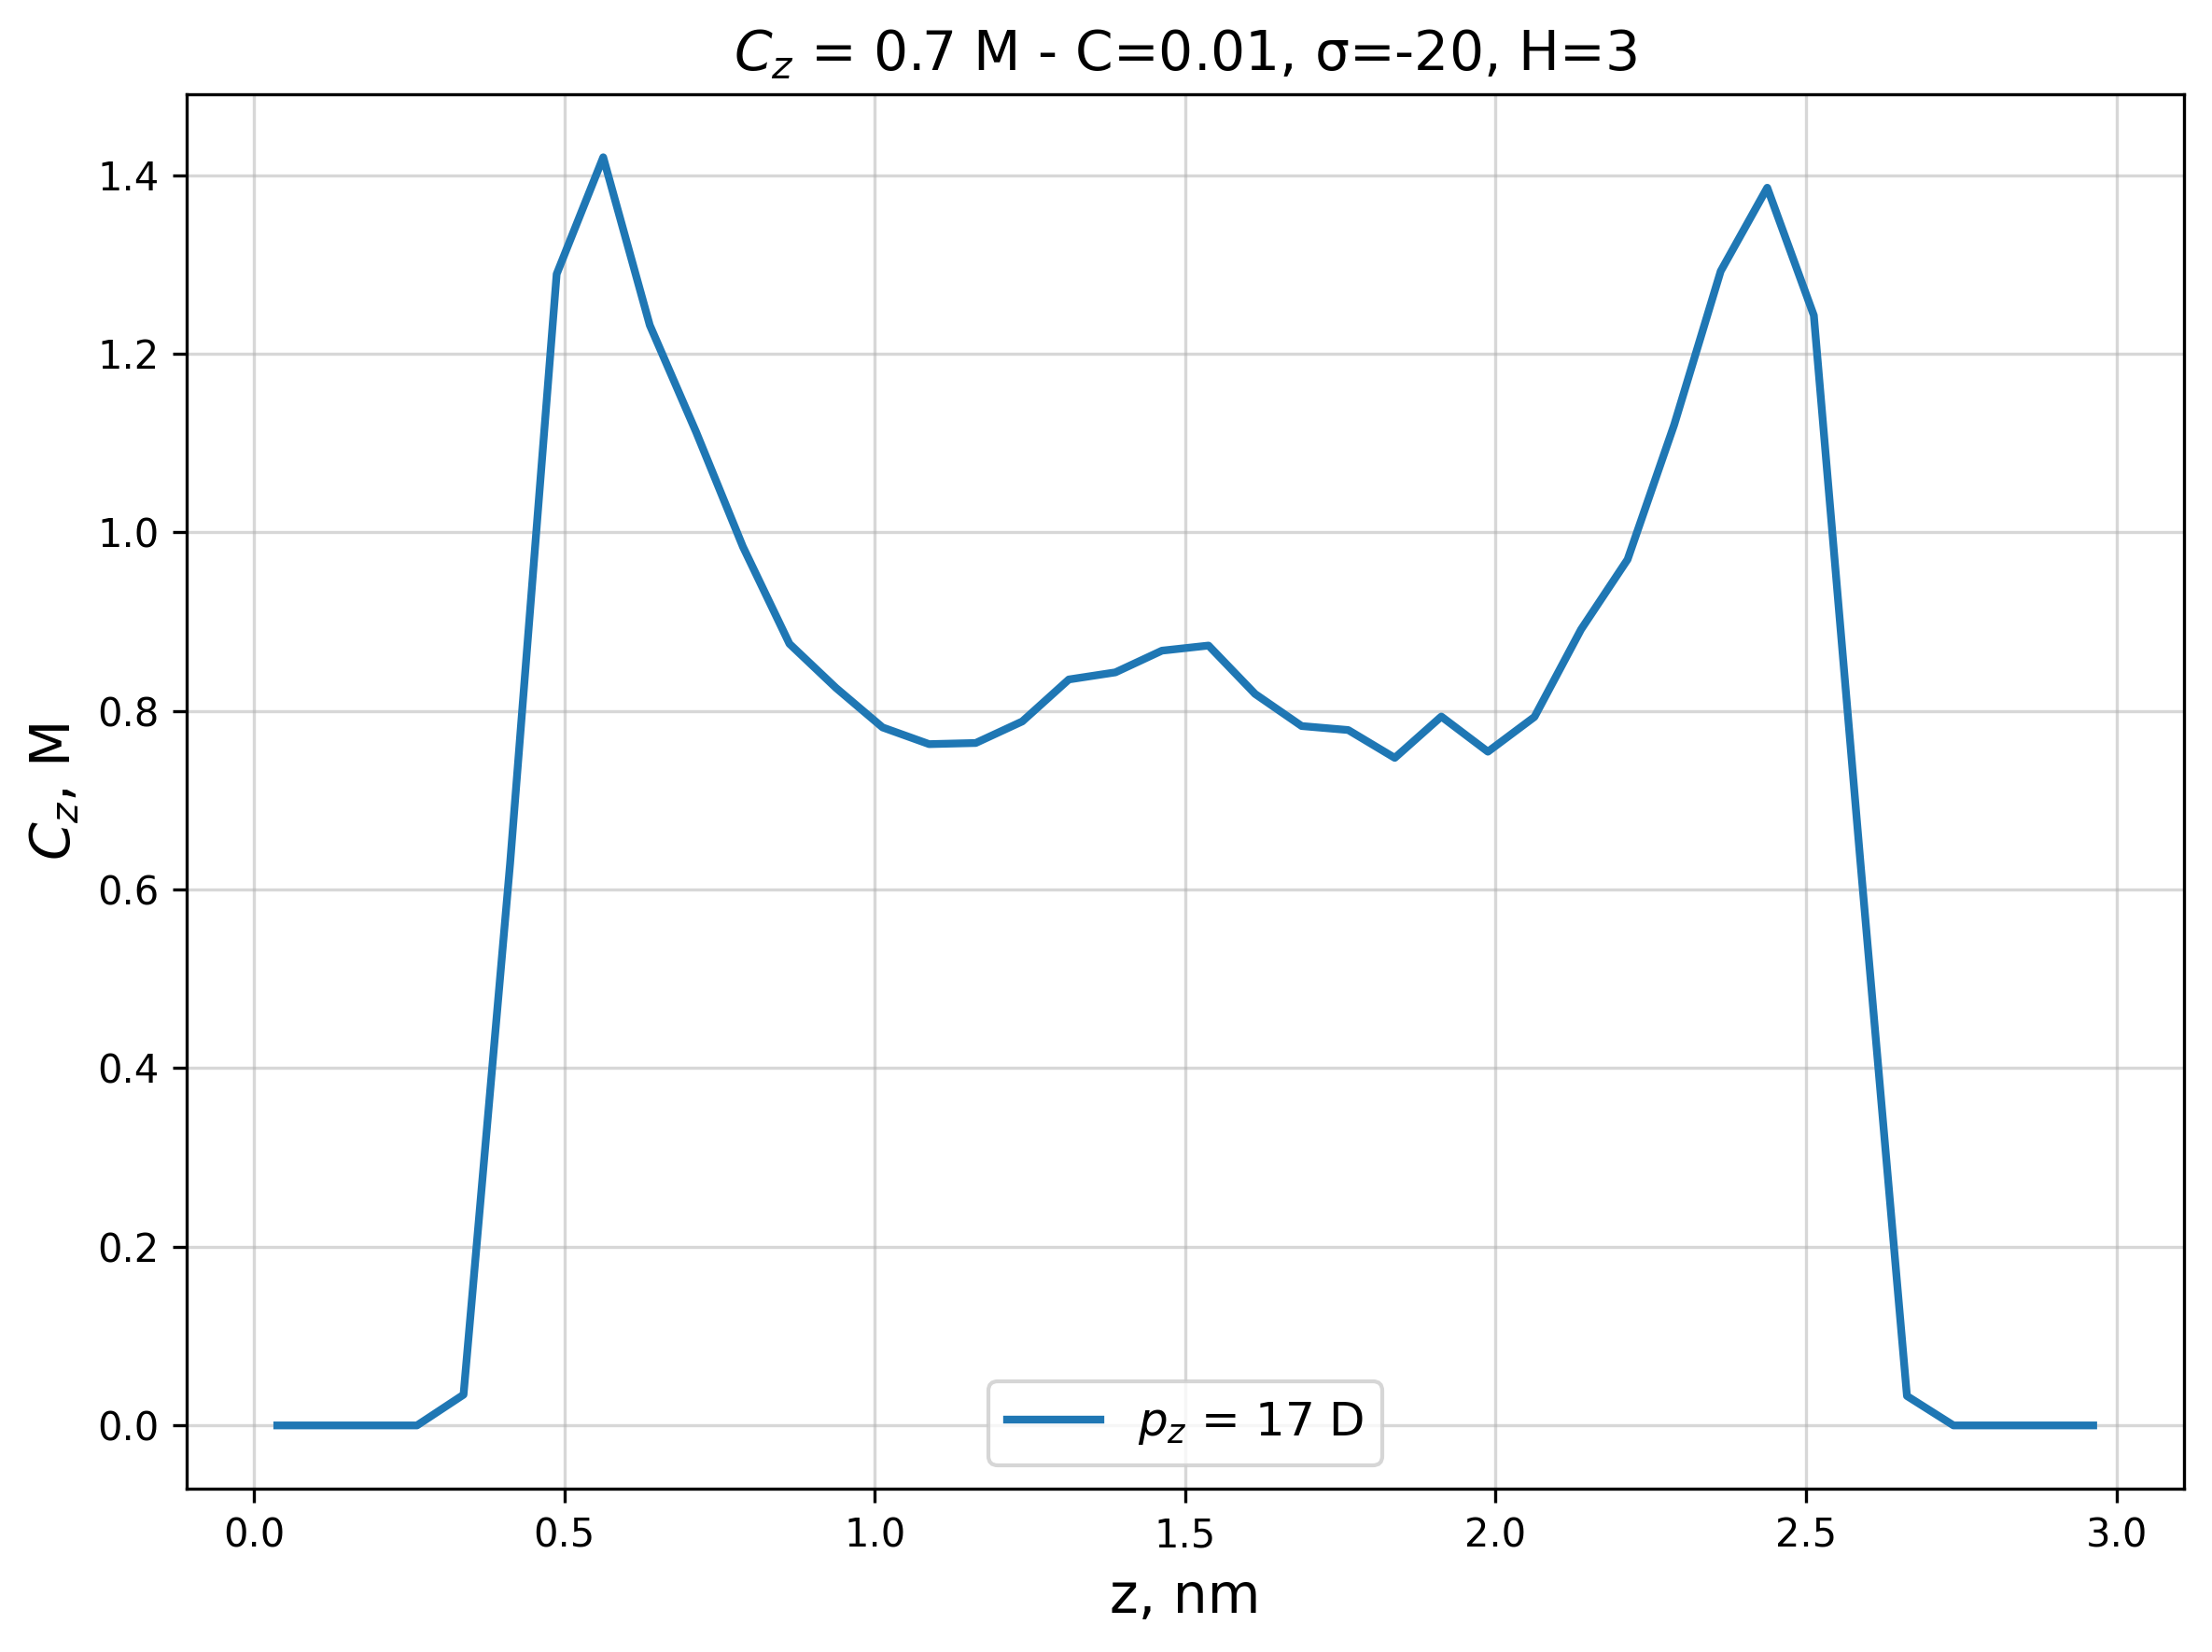

In [8]:
import yaml
from density_profile import read_xyz_trajectory

# System parameters to match
C = 0.01  # mol/l
Cz = 0.7  # mol/l - only plot for this value
sigma = -20  # µC/cm²
H = 3  # nm

# Frame selection for profile calculation
START_FRAME = 4000  # Start from this frame (0 = from beginning)
END_FRAME = None  # End at this frame (None = use all frames)

# PZ_LIST = ["pz_17", "pz_27p6"]
PZ_LIST = ["pz_17"]
RESULTS_ROOT = "results_prod"
MOL_CONV = 1.66053907  # 1/nm^3 -> mol/l
PROFILE_BINS = 40

POSITIVE_SPECIES = ("Na",)
NEGATIVE_SPECIES = ("Cl",)
ZWITTERION_SPECIES = ("G",)  # Only G atoms represent zwitterion centers
TRAJ_CACHE_FILENAME = "trajectory_cache.npz"


def extract_params_from_folder(folder_name: str, config: dict) -> dict:
    """Extract C, Cz, sigma, H from folder name or config."""
    params = {}
    parts = folder_name.split("_")

    for key in ["C", "Cz", "H", "sigma"]:
        if key in config:
            params[key] = float(config[key])
        else:
            for idx, token in enumerate(parts):
                if token == key and idx + 1 < len(parts):
                    try:
                        val = parts[idx + 1]
                        params[key] = float(val)
                        break
                    except (ValueError, IndexError):
                        pass

    return params


def find_matching_folder(pz: str, target_C: float, target_Cz: float, target_sigma: float, target_H: float) -> str | None:
    """Find folder matching the specified parameters."""
    tolerance = 1e-3

    for sweep in ["C", "Cz", "H", "sigma"]:
        sweep_dir = osp.join(RESULTS_ROOT, pz, sweep)
        if not osp.isdir(sweep_dir):
            continue

        for folder in os.listdir(sweep_dir):
            calc_dir = osp.join(sweep_dir, folder)
            config_path = osp.join(calc_dir, "config_backup.yaml")
            traj_path = osp.join(calc_dir, "trajectory.xyz")

            if not (osp.isfile(config_path) and osp.isfile(traj_path)):
                continue

            try:
                with open(config_path, "r") as f:
                    config = yaml.safe_load(f) or {}

                params = extract_params_from_folder(folder, config)

                if all(key in params for key in ["C", "Cz", "sigma", "H"]):
                    if (abs(params["C"] - target_C) < tolerance and
                        abs(params["Cz"] - target_Cz) < tolerance and
                        abs(params["sigma"] - target_sigma) < tolerance and
                        abs(params["H"] - target_H) < tolerance):
                        return calc_dir
            except Exception:
                continue

    return None


def load_or_cache_trajectory(traj_path: str, cache_path: str) -> tuple:
    """Load trajectory, caching to file for faster subsequent reads."""
    if osp.isfile(cache_path):
        with np.load(cache_path, allow_pickle=True) as data:
            positions = data["positions"]
            species = data["species"]
            boxes = data["boxes"]
        return positions, species, boxes

    positions, species, _charges, boxes, _energies = read_xyz_trajectory(traj_path)

    np.savez(
        cache_path,
        positions=positions,
        species=species,
        boxes=boxes,
    )

    return positions, species, boxes


def build_density_profile(positions: np.ndarray, species: np.ndarray, boxes: np.ndarray, species_list: tuple, n_bins: int, start_frame: int = 0, end_frame: int | None = None) -> dict:
    """Build density profile for specified species."""
    Lx = float(boxes[0, 0])
    Ly = float(boxes[0, 4])
    H = float(boxes[0, 8])

    n_frames_total = positions.shape[0]
    start_frame = max(0, min(start_frame, n_frames_total - 1))
    end_frame = end_frame if end_frame is not None else n_frames_total
    end_frame = min(end_frame, n_frames_total)

    frame_indices = range(start_frame, end_frame)
    n_frames_used = len(frame_indices)

    if n_frames_used == 0:
        raise ValueError(f"No frames in range [{start_frame}, {end_frame})")

    area_xy = Lx * Ly
    z_edges = np.linspace(0.0, H, n_bins + 1, dtype=np.float64)
    bin_height = z_edges[1] - z_edges[0]
    bin_volume = area_xy * bin_height
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

    accum_counts = np.zeros(n_bins, dtype=np.float64)

    for frame_idx in frame_indices:
        frame_positions = positions[frame_idx]
        frame_species = species[frame_idx]
        mask = np.isin(frame_species, species_list)
        z_coords = frame_positions[mask, 2]

        if z_coords.size > 0:
            counts, _ = np.histogram(z_coords, bins=z_edges)
            accum_counts += counts

    mean_counts = accum_counts / n_frames_used
    density_mol_l = (mean_counts / bin_volume) * MOL_CONV

    return {
        "z_centers": z_centers,
        "density_profile": density_mol_l,
        "H": H,
        "Lx": Lx,
        "Ly": Ly,
        "n_frames_used": n_frames_used,
        "start_frame": start_frame,
        "end_frame": end_frame,
    }


# Find matching folders and build profiles for Cz=0.7
profile_data = {}
for pz in PZ_LIST:
    folder = find_matching_folder(pz, C, Cz, sigma, H)
    if folder is None:
        print(f"Warning: No matching folder found for {pz} with C={C}, Cz={Cz}, sigma={sigma}, H={H}")
        continue

    traj_path = osp.join(folder, "trajectory.xyz")
    cache_path = osp.join(folder, TRAJ_CACHE_FILENAME)

    if not osp.isfile(traj_path):
        print(f"Warning: Trajectory not found in {folder}")
        continue

    print(f"Processing {pz}, Cz={Cz}: {folder}")

    # Load or cache trajectory
    positions, species, boxes = load_or_cache_trajectory(traj_path, cache_path)

    n_frames_total = positions.shape[0]
    end_frame_actual = END_FRAME if END_FRAME is not None else n_frames_total
    end_frame_actual = min(end_frame_actual, n_frames_total)
    frames_to_use = end_frame_actual - START_FRAME
    print(f"  Using frames {START_FRAME} to {end_frame_actual-1} ({frames_to_use} frames out of {n_frames_total} total)")

    # Build profiles for zwitterions only
    try:
        profile_data[pz] = build_density_profile(positions, species, boxes, ZWITTERION_SPECIES, PROFILE_BINS, START_FRAME, END_FRAME)
    except Exception as exc:
        print(f"  Error processing zwitterion ions: {exc}")
        import traceback
        traceback.print_exc()

# Plot results - single figure with both pz values for Cz=0.7
if profile_data:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    colors = {"pz_17": "tab:blue", "pz_27p6": "tab:orange"}
    labels = {"pz_17": "$p_z$ = 17 D", "pz_27p6": "$p_z$ = 27.6 D"}

    # Plot zwitterions for both pz values
    for pz in PZ_LIST:
        if pz not in profile_data:
            continue

        profile = profile_data[pz]
        ax.plot(
            profile["z_centers"],
            profile["density_profile"],
            color=colors[pz],
            label=labels[pz],
            linewidth=2,
        )

    ax.set_xlabel("z, nm", fontsize=14)
    ax.set_ylabel(r"$C_z$, M", fontsize=14)
    ax.grid(alpha=0.5)
    ax.legend(loc="best", fontsize=12)
    ax.set_title(f"$C_z$ = {Cz} M - C={C}, σ={sigma}, H={H}", fontsize=14)

    plt.tight_layout()
    plt.show()

else:
    print("No matching data found for the specified parameters.")



Processing pz_27p6, Cz=0.1, σ=0: results_prod/pz_27p6/sigma/ions_dipole_sigma_pz_27p6_H_3_sigma_0_C_0.01_Cz_0.1_20251124_154912
  Using frames 2000 to 19999 (18000 frames out of 20000 total)
Processing pz_27p6, Cz=0.1, σ=-30: results_prod/pz_27p6/sigma/ions_dipole_sigma_pz_27p6_H_3_sigma_-30_C_0.01_Cz_0.1_20251124_154912
  Using frames 2000 to 19999 (18000 frames out of 20000 total)


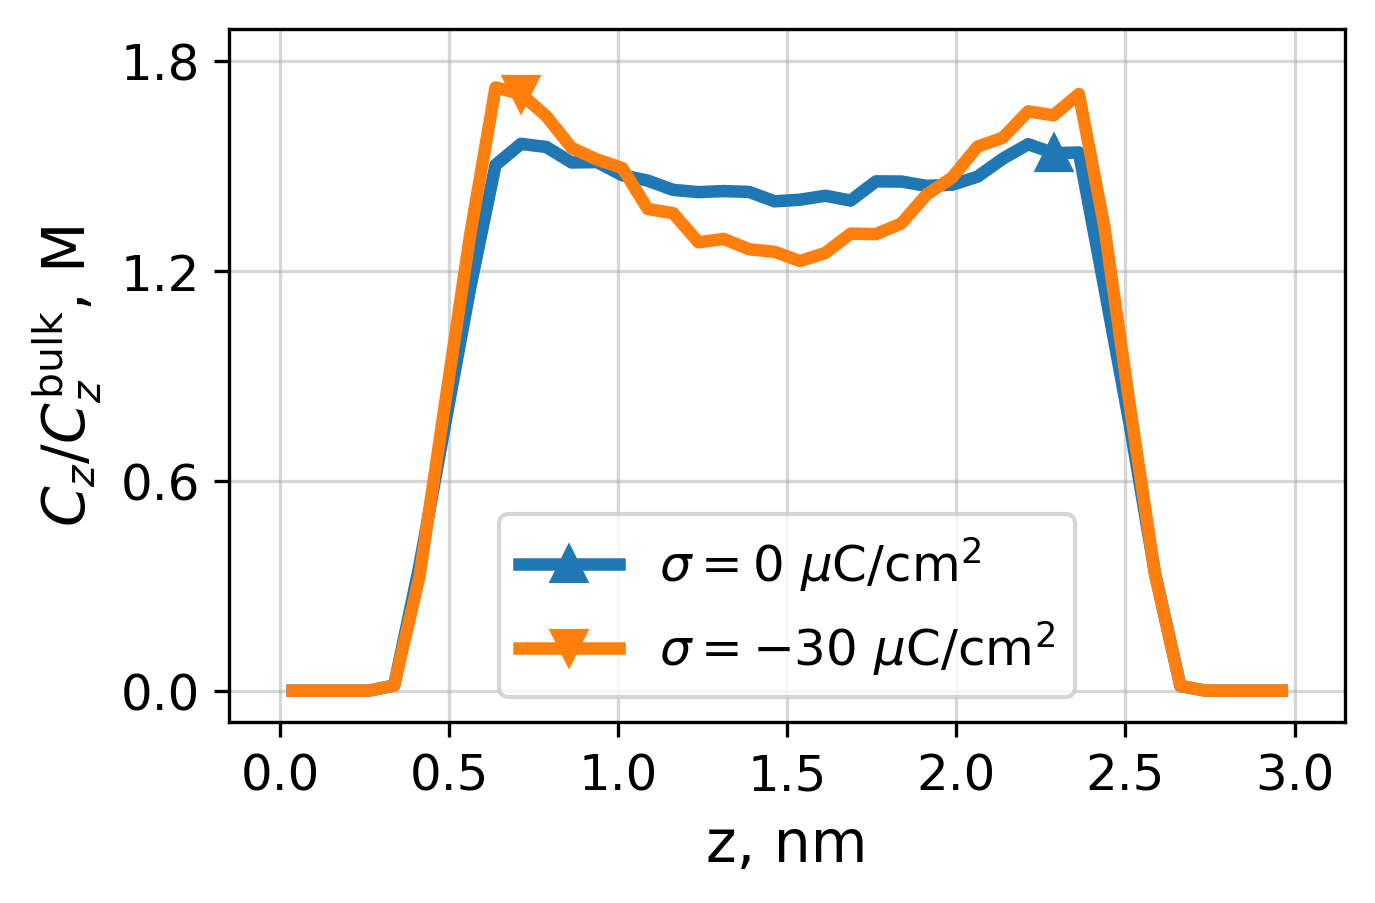

In [37]:
import yaml
from density_profile import read_xyz_trajectory

# System parameters to match
C = 0.01  # mol/l
Cz = 0.1  # mol/l
sigma_values = [0, -30]  # µC/cm² - will plot profiles for both values
H = 3  # nm
# pz = "pz_17"  # Only pz_17
pz = "pz_27p6"  # Only pz_17
scale = 1.2

# Frame selection for profile calculation
START_FRAME = 2000  # Start from this frame (0 = from beginning)
END_FRAME = None  # End at this frame (None = use all frames)

RESULTS_ROOT = "results_prod"
MOL_CONV = 1.66053907  # 1/nm^3 -> mol/l
PROFILE_BINS = 40

ZWITTERION_SPECIES = ("G",)  # Only G atoms represent zwitterion centers
TRAJ_CACHE_FILENAME = "trajectory_cache.npz"

def extract_params_from_folder(folder_name: str, config: dict) -> dict:
    params = {}
    parts = folder_name.split("_")
    for key in ["C", "Cz", "H", "sigma"]:
        if key in config:
            params[key] = float(config[key])
        else:
            for idx, token in enumerate(parts):
                if token == key and idx + 1 < len(parts):
                    try:
                        val = parts[idx + 1]
                        params[key] = float(val)
                        break
                    except (ValueError, IndexError):
                        pass
    return params

def find_matching_folder(pz: str, target_C: float, target_Cz: float, target_sigma: float, target_H: float) -> str | None:
    tolerance = 1e-3
    for sweep in ["C", "Cz", "H", "sigma"]:
        sweep_dir = osp.join(RESULTS_ROOT, pz, sweep)
        if not osp.isdir(sweep_dir):
            continue
        for folder in os.listdir(sweep_dir):
            calc_dir = osp.join(sweep_dir, folder)
            config_path = osp.join(calc_dir, "config_backup.yaml")
            traj_path = osp.join(calc_dir, "trajectory.xyz")
            if not (osp.isfile(config_path) and osp.isfile(traj_path)):
                continue
            try:
                with open(config_path, "r") as f:
                    config = yaml.safe_load(f) or {}
                params = extract_params_from_folder(folder, config)
                if all(key in params for key in ["C", "Cz", "sigma", "H"]):
                    if (abs(params["C"] - target_C) < tolerance and
                        abs(params["Cz"] - target_Cz) < tolerance and
                        abs(params["sigma"] - target_sigma) < tolerance and
                        abs(params["H"] - target_H) < tolerance):
                        return calc_dir
            except Exception:
                continue
    return None

def load_or_cache_trajectory(traj_path: str, cache_path: str) -> tuple:
    if osp.isfile(cache_path):
        with np.load(cache_path, allow_pickle=True) as data:
            positions = data["positions"]
            species = data["species"]
            boxes = data["boxes"]
        return positions, species, boxes
    positions, species, _charges, boxes, _energies = read_xyz_trajectory(traj_path)
    np.savez(
        cache_path,
        positions=positions,
        species=species,
        boxes=boxes,
    )
    return positions, species, boxes

def build_density_profile(positions: np.ndarray, species: np.ndarray, boxes: np.ndarray, species_list: tuple, n_bins: int, start_frame: int = 0, end_frame: int | None = None) -> dict:
    Lx = float(boxes[0, 0])
    Ly = float(boxes[0, 4])
    H = float(boxes[0, 8])
    n_frames_total = positions.shape[0]
    start_frame = max(0, min(start_frame, n_frames_total - 1))
    end_frame = end_frame if end_frame is not None else n_frames_total
    end_frame = min(end_frame, n_frames_total)
    frame_indices = range(start_frame, end_frame)
    n_frames_used = len(frame_indices)
    if n_frames_used == 0:
        raise ValueError(f"No frames in range [{start_frame}, {end_frame})")
    area_xy = Lx * Ly
    z_edges, bin_height = np.linspace(0.0, H, n_bins + 1, dtype=np.float64, retstep=True)
    bin_volume = area_xy * bin_height
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])
    accum_counts = np.zeros(n_bins, dtype=np.float64)
    for frame_idx in frame_indices:
        frame_positions = positions[frame_idx]
        frame_species = species[frame_idx]
        mask = np.isin(frame_species, species_list)
        z_coords = frame_positions[mask, 2]
        if z_coords.size > 0:
            counts, _ = np.histogram(z_coords, bins=z_edges)
            accum_counts += counts
    mean_counts = accum_counts / n_frames_used
    density_mol_l = (mean_counts / bin_volume) * MOL_CONV
    return {
        "z_centers": z_centers,
        "density_profile": density_mol_l,
        "H": H,
        "Lx": Lx,
        "Ly": Ly,
        "n_frames_used": n_frames_used,
        "start_frame": start_frame,
        "end_frame": end_frame,
    }

# Build profiles for both sigma values
profile_data = {}
for sigma in sigma_values:
    folder = find_matching_folder(pz, C, Cz, sigma, H)
    if folder is None:
        print(f"Warning: No matching folder found for {pz} with C={C}, Cz={Cz}, sigma={sigma}, H={H}")
        continue
    traj_path = osp.join(folder, "trajectory.xyz")
    cache_path = osp.join(folder, TRAJ_CACHE_FILENAME)
    if not osp.isfile(traj_path):
        print(f"Warning: Trajectory not found in {folder}")
        continue
    print(f"Processing {pz}, Cz={Cz}, σ={sigma}: {folder}")

    positions, species, boxes = load_or_cache_trajectory(traj_path, cache_path)

    n_frames_total = positions.shape[0]
    end_frame_actual = END_FRAME if END_FRAME is not None else n_frames_total
    end_frame_actual = min(end_frame_actual, n_frames_total)
    frames_to_use = end_frame_actual - START_FRAME
    print(f"  Using frames {START_FRAME} to {end_frame_actual-1} ({frames_to_use} frames out of {n_frames_total} total)")

    try:
        profile_data[sigma] = build_density_profile(positions, species, boxes, ZWITTERION_SPECIES, PROFILE_BINS, START_FRAME, END_FRAME)
    except Exception as exc:
        print(f"  Error processing zwitterion ions: {exc}")
        import traceback
        traceback.print_exc()

# --- Plotting according to new style (all solid, mark maxima with triangles, control maxima placement) ---

if profile_data:
    fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)

    sigma_order = [0, -30]
    color_map = {sigma_order[0]: COLORS[0], sigma_order[1]: COLORS[1]}
    label_map = {0: r"$\sigma = 0\ \mu$C/cm$^2$", -30: r"$\sigma = -30\ \mu$C/cm$^2$"}
    linestyle_map = {0: '-', -30: '-'}

    # Prepare curves normalized to Cz
    curve_x_y = {}
    for sigma in sigma_order:
        if sigma not in profile_data:
            continue
        prof = profile_data[sigma]
        xvals = prof["z_centers"]
        yvals = prof["density_profile"] / Cz
        curve_x_y[sigma] = (xvals, yvals)

    # Control maxima placement:
    # For 0 μC/cm², marker on *right* (z > mid), and for -30 μC/cm², marker on *left* (z < mid)
    x_min, x_max = 0, 3  # Use limits set for plotting
    z_middle = (x_min + x_max) / 2

    max_x_for_sigma = {}
    max_y_for_sigma = {}

    # Find leftmost maximum for -30 and rightmost for 0 (both exclusive halves)
    for sigma in sigma_order:
        if sigma not in curve_x_y:
            continue
        x, y = curve_x_y[sigma]
        if sigma == 0:
            # right half: x > z_middle
            mask = x > z_middle
        else:
            # left half: x < z_middle
            mask = x < z_middle
        if np.sum(mask) == 0:  # fallback: global max
            max_idx = np.argmax(y)
        else:
            candidate_idx = np.where(mask)[0]
            max_idx_in_half = candidate_idx[np.argmax(y[mask])]
            max_idx = max_idx_in_half

        if sigma == 0:
            max_idx += 1
        else:
            max_idx += 1

        max_x_for_sigma[sigma] = x[max_idx]
        max_y_for_sigma[sigma] = y[max_idx]

    # Plot both curves as solid lines only
    for sigma in sigma_order:
        if sigma not in curve_x_y:
            continue
        x, y = curve_x_y[sigma]
        ax.plot(
            x, y,
            color=color_map[sigma],
            linestyle=linestyle_map[sigma],
            linewidth=3,
            # No markers for lines
            # label=label_map[sigma],
        )

    # Overlay triangles at maxima for each curve, one left and one right
    # -30 gets triangle down on left, 0 gets triangle up on right
    if (-30 in max_x_for_sigma) and (0 in max_x_for_sigma):
        ax.plot(
            [max_x_for_sigma[sigma_order[0]]], [max_y_for_sigma[sigma_order[0]]],
            color=color_map[sigma_order[0]],
            linestyle=linestyle_map[sigma_order[0]],
            linewidth=3,
            marker='^',
            markersize=8,
            label=label_map[sigma_order[0]],
            zorder=10
        )
        ax.plot(
            [max_x_for_sigma[sigma_order[1]]], [max_y_for_sigma[sigma_order[1]]],
            color=color_map[sigma_order[1]],
            linestyle=linestyle_map[sigma_order[1]],
            linewidth=3,
            marker='v',
            markersize=8,
            label=label_map[sigma_order[1]],
            zorder=10
        )

        # ax.plot(
        #     cz_values,
        #     surface_values,
        #     label=r"$p_z$: 17 D" if PZ_LIST[pzi] == "pz_17" else r"$p_z$: 27.6 D",
        #     color=COLORS[pzi],
        #     linestyle='-' if pzi == 0 else '--',
        #     linewidth=2.5,
        #     marker="v" if pzi == 0 else "^",
        #     markersize=10,
        # )

    # Axis setup following style
    pct = 0.05
    # z_all = np.concatenate([curve_x_y[s][0] for s in sigma_order if s in curve_x_y])
    # x_min, x_max = np.nanmin(z_all), np.nanmax(z_all)
    x_min, x_max = 0, 3
    ax.set_xlim(x_min - pct * (x_max - x_min), x_max + pct * (x_max - x_min))
    y_min, y_max = 0, 1.8
    ax.set_ylim(y_min - pct * (y_max - y_min), y_max + pct * (y_max - y_min))

    ax.set_xticks(np.linspace(x_min, x_max, 7, endpoint=True))
    ax.set_yticks(np.linspace(y_min, y_max, 4, endpoint=True))

    # ax.xaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))
    # ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))

    ax.grid(alpha=0.5)

    ax.set_xlabel("z, nm", fontsize=14)
    ax.set_ylabel(fr"$C_z$/$C_z^\text{{bulk}}$, M", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)

    plt.show()
else:
    print("No matching data found for the specified parameters.")



In [25]:
np.trapezoid(profile["density_profile"], profile["z_centers"])

np.float64(0.0996323442)

In [ ]:
np.sum(profile["density_profile"]) * (profile["z_centers"][1] - profile["z_centers"][0]) / 3

np.float64(0.09963234419999999)

Processing pz_27p6, Cz=0.1, σ=-20: results_prod/pz_27p6/C/ions_dipole_C_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.1_20251124_154912
  Using frames 2000 to 19999 (18000 frames out of 20000 total)
Processing pz_27p6, Cz=0.7, σ=-20: results_prod/pz_27p6/Cz/ions_dipole_Cz_pz_27p6_H_3_sigma_-20_C_0.01_Cz_0.7_20251124_154916
  Using frames 2000 to 19999 (18000 frames out of 20000 total)


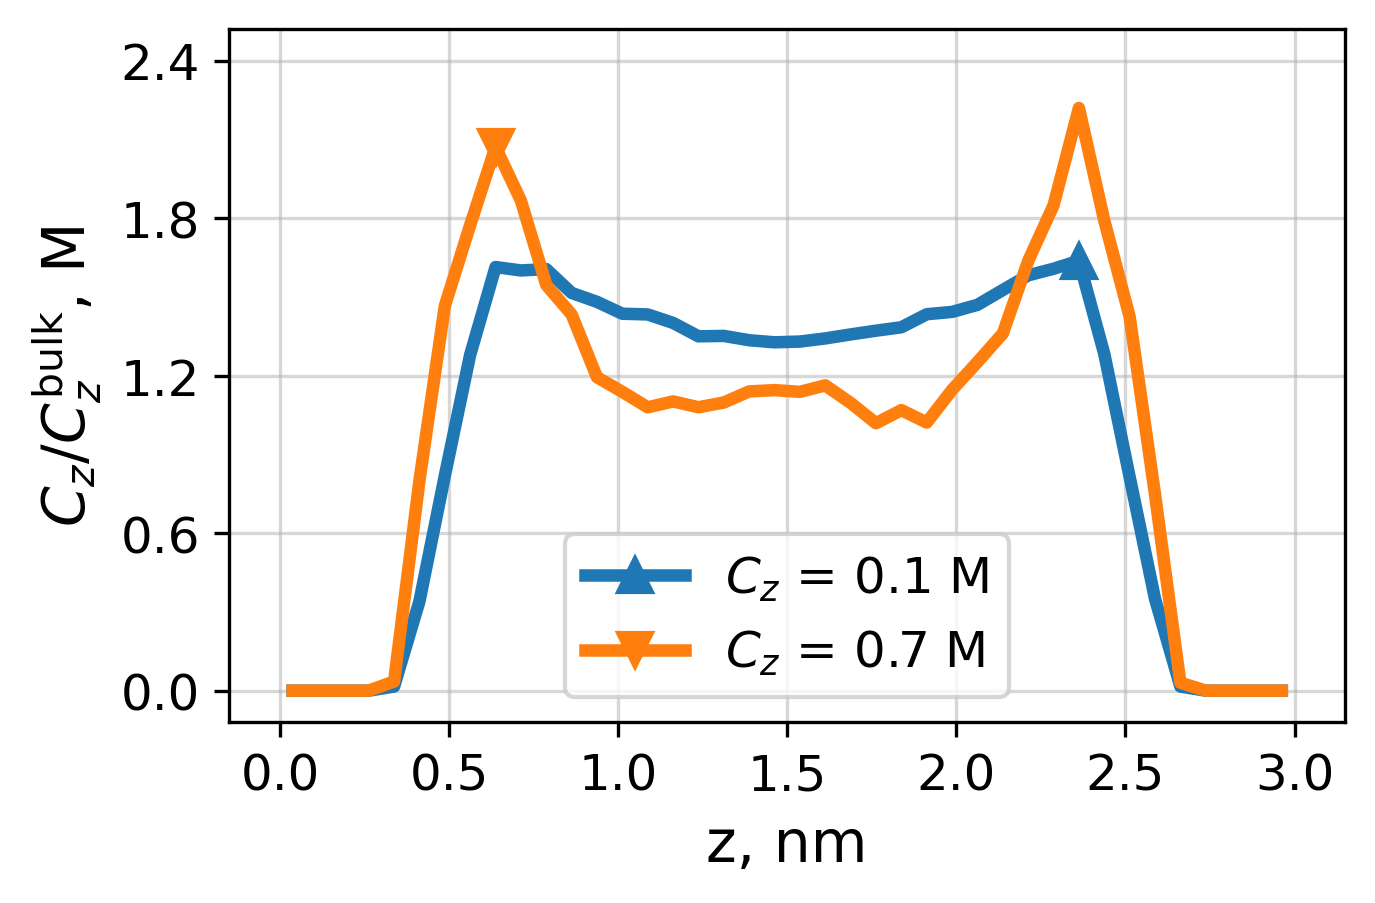

In [46]:
import yaml
from density_profile import read_xyz_trajectory

# System parameters to match
C = 0.01  # mol/l
Cz_values = [0.1, 0.7]  # mol/l (plot both)
sigma = -20  # µC/cm²
H = 3  # nm
# pz = "pz_17"
pz = "pz_27p6"
scale = 1.2

# Frame selection
START_FRAME = 2000
END_FRAME = None

RESULTS_ROOT = "results_prod"
MOL_CONV = 1.66053907  # 1/nm^3 -> mol/l
PROFILE_BINS = 40

ZWITTERION_SPECIES = ("G",)
TRAJ_CACHE_FILENAME = "zwitterion_cache.npz"

def extract_params_from_folder(folder_name: str, config: dict) -> dict:
    params = {}
    parts = folder_name.split("_")
    for key in ["C", "Cz", "H", "sigma"]:
        if key in config:
            params[key] = float(config[key])
        else:
            for idx, token in enumerate(parts):
                if token == key and idx + 1 < len(parts):
                    try:
                        val = parts[idx + 1]
                        params[key] = float(val)
                        break
                    except (ValueError, IndexError):
                        pass
    return params

def find_matching_folder(pz: str, target_C: float, target_Cz: float, target_sigma: float, target_H: float) -> str | None:
    tolerance = 1e-3
    for sweep in ["C", "Cz", "H", "sigma"]:
        sweep_dir = osp.join(RESULTS_ROOT, pz, sweep)
        if not osp.isdir(sweep_dir):
            continue
        for folder in os.listdir(sweep_dir):
            calc_dir = osp.join(sweep_dir, folder)
            config_path = osp.join(calc_dir, "config_backup.yaml")
            traj_path = osp.join(calc_dir, "trajectory.xyz")
            if not (osp.isfile(config_path) and osp.isfile(traj_path)):
                continue
            try:
                with open(config_path, "r") as f:
                    config = yaml.safe_load(f) or {}
                params = extract_params_from_folder(folder, config)
                if all(key in params for key in ["C", "Cz", "sigma", "H"]):
                    if (abs(params["C"] - target_C) < tolerance and
                        abs(params["Cz"] - target_Cz) < tolerance and
                        abs(params["sigma"] - target_sigma) < tolerance and
                        abs(params["H"] - target_H) < tolerance):
                        return calc_dir
            except Exception:
                continue
    return None

def load_or_cache_trajectory(traj_path: str, cache_path: str) -> tuple:
    if osp.isfile(cache_path):
        with np.load(cache_path, allow_pickle=True) as data:
            positions = data["positions"]
            species = data["species"]
            boxes = data["boxes"]
        return positions, species, boxes
    positions, species, _charges, boxes, _energies = read_xyz_trajectory(traj_path)
    np.savez(
        cache_path,
        positions=positions,
        species=species,
        boxes=boxes,
    )
    return positions, species, boxes

def build_density_profile(
    positions: np.ndarray,
    species: np.ndarray,
    boxes: np.ndarray,
    species_list: tuple,
    n_bins: int,
    start_frame: int = 0,
    end_frame: int | None = None
) -> dict:
    Lx = float(boxes[0, 0])
    Ly = float(boxes[0, 4])
    H = float(boxes[0, 8])
    n_frames_total = positions.shape[0]
    start_frame = max(0, min(start_frame, n_frames_total - 1))
    end_frame = end_frame if end_frame is not None else n_frames_total
    end_frame = min(end_frame, n_frames_total)
    frame_indices = range(start_frame, end_frame)
    n_frames_used = len(frame_indices)
    if n_frames_used == 0:
        raise ValueError(f"No frames in range [{start_frame}, {end_frame})")
    area_xy = Lx * Ly
    z_edges, bin_height = np.linspace(0.0, H, n_bins + 1, dtype=np.float64, retstep=True)
    bin_volume = area_xy * bin_height
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])
    accum_counts = np.zeros(n_bins, dtype=np.float64)
    for frame_idx in frame_indices:
        frame_positions = positions[frame_idx]
        frame_species = species[frame_idx]
        mask = np.isin(frame_species, species_list)
        z_coords = frame_positions[mask, 2]
        if z_coords.size > 0:
            counts, _ = np.histogram(z_coords, bins=z_edges)
            accum_counts += counts
    mean_counts = accum_counts / n_frames_used
    density_mol_l = (mean_counts / bin_volume) * MOL_CONV
    return {
        "z_centers": z_centers,
        "density_profile": density_mol_l,
        "H": H,
        "Lx": Lx,
        "Ly": Ly,
        "n_frames_used": n_frames_used,
        "start_frame": start_frame,
        "end_frame": end_frame,
    }

profile_data = {}
for Cz in Cz_values:
    folder = find_matching_folder(pz, C, Cz, sigma, H)
    if folder is None:
        print(f"Warning: No matching folder found for {pz} with C={C}, Cz={Cz}, sigma={sigma}, H={H}")
        continue
    traj_path = osp.join(folder, "trajectory.xyz")
    cache_path = osp.join(folder, TRAJ_CACHE_FILENAME)
    if not osp.isfile(traj_path):
        print(f"Warning: Trajectory not found in {folder}")
        continue
    print(f"Processing {pz}, Cz={Cz}, σ={sigma}: {folder}")
    positions, species, boxes = load_or_cache_trajectory(traj_path, cache_path)
    n_frames_total = positions.shape[0]
    end_frame_actual = END_FRAME if END_FRAME is not None else n_frames_total
    end_frame_actual = min(end_frame_actual, n_frames_total)
    frames_to_use = end_frame_actual - START_FRAME
    print(f"  Using frames {START_FRAME} to {end_frame_actual-1} ({frames_to_use} frames out of {n_frames_total} total)")
    try:
        profile_data[Cz] = build_density_profile(
            positions, species, boxes, ZWITTERION_SPECIES, PROFILE_BINS, START_FRAME, END_FRAME
        )
    except Exception as exc:
        print(f"  Error processing zwitterion ions: {exc}")
        import traceback
        traceback.print_exc()

if profile_data:
    fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)

    color_map = {Cz_values[0]: COLORS[0], Cz_values[1]: COLORS[1]}
    label_map = {Cz_values[0]: r"$C_z$ = 0.1 M", Cz_values[1]: r"$C_z$ = 0.7 M"}
    linestyle_map = {Cz_values[0]: '-', Cz_values[1]: '-'}

    # Prepare curves normalized to Cz
    curve_x_y = {}
    for Cz in Cz_values:
        if Cz not in profile_data:
            continue
        prof = profile_data[Cz]
        xvals = prof["z_centers"]
        yvals = prof["density_profile"] / Cz
        curve_x_y[Cz] = (xvals, yvals)

    # Control maxima placement:
    # For 0 μC/cm², marker on *right* (z > mid), and for -30 μC/cm², marker on *left* (z < mid)
    x_min, x_max = 0, 3  # Use limits set for plotting
    z_middle = (x_min + x_max) / 2

    max_x_for_Cz = {}
    max_y_for_Cz = {}

    # Find leftmost maximum for -30 and rightmost for 0 (both exclusive halves)
    for Cz in Cz_values:
        if Cz not in curve_x_y:
            continue
        x, y = curve_x_y[Cz]
        if Cz == 0.1:
            # right half: x > z_middle
            mask = x > z_middle
        else:
            # left half: x < z_middle
            mask = x < z_middle
        if np.sum(mask) == 0:  # fallback: global max
            max_idx = np.argmax(y)
        else:
            candidate_idx = np.where(mask)[0]
            max_idx_in_half = candidate_idx[np.argmax(y[mask])]
            max_idx = max_idx_in_half

        # if Cz == 0.1:
        #     max_idx += 1
        # else:
        #     max_idx += 1

        max_x_for_Cz[Cz] = x[max_idx]
        max_y_for_Cz[Cz] = y[max_idx]


    # Plot both curves as solid lines (no markers except at highlighted point)
    for idx, Cz in enumerate(Cz_values):
        if Cz not in profile_data:
            continue
        x, y = curve_x_y[Cz]
        ax.plot(
            x, y,
            color=color_map[Cz],
            linestyle=linestyle_map[Cz],
            linewidth=3,
            # No markers for lines
            # label=label_map[sigma],
        )

    # Overlay triangles at (x_mark, y1/y2) using triangle up and triangle down, matching style
    if (0.1 in max_x_for_Cz) and (0.7 in max_x_for_Cz):
        ax.plot(
            [max_x_for_Cz[Cz_values[0]]], [max_y_for_Cz[Cz_values[0]]],
            color=color_map[Cz_values[0]],
            linestyle=linestyle_map[Cz_values[0]],
            linewidth=3,
            marker='^',
            markersize=8,
            label=label_map[Cz_values[0]],
            zorder=10
        )
        ax.plot(
            [max_x_for_Cz[Cz_values[1]]], [max_y_for_Cz[Cz_values[1]]],
            color=color_map[Cz_values[1]],
            linestyle=linestyle_map[Cz_values[1]],
            linewidth=3,
            marker='v',
            markersize=8,
            label=label_map[Cz_values[1]],
            zorder=10
        )


    # Axis setup following style
    pct = 0.05
    # z_all = np.concatenate([curve_x_y[s][0] for s in sigma_order if s in curve_x_y])
    # x_min, x_max = np.nanmin(z_all), np.nanmax(z_all)
    ax.set_xlim(x_min - pct * (x_max - x_min), x_max + pct * (x_max - x_min))
    y_min, y_max = 0, 2.4
    ax.set_ylim(y_min - pct * (y_max - y_min), y_max + pct * (y_max - y_min))

    ax.set_xticks(np.linspace(x_min, x_max, 7, endpoint=True))
    ax.set_yticks(np.linspace(y_min, y_max, 5, endpoint=True))

    # ax.xaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))
    # ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins='auto'))

    ax.grid(alpha=0.5)

    ax.set_xlabel("z, nm", fontsize=14)
    ax.set_ylabel(fr"$C_z$/$C_z^\text{{bulk}}$, M", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)

    plt.show()
else:
    print("No matching data found for the specified parameters.")

